# smFISH segmentation and intensity analysis

This notebook was used for segmentation of nuclei, nuclear speckles and cell territories, followed by per-cell smFISH intensity measurements in the cell, cytoplasm, nucleus, speckles and nucleoplasm.

The notebook was run separately for individual replicate/condition folders. The code cells are left unchanged here as a record of the analysis that was run. Run-specific paths and parameters are defined in the parameter cells below.

A few inline comments/docstrings were carried over from earlier versions of the analysis. Where these differ from the active parameter values, the values set in the code cells are the ones that were used.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import tifffile as tiff
import matplotlib.pyplot as plt

from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, binary_closing, disk
from skimage.segmentation import find_boundaries
from skimage.measure import label, regionprops_table
from skimage.exposure import rescale_intensity
from tqdm.auto import tqdm

# Cellpose-SAM / Cellpose v4
from cellpose import models

from skimage.measure import label, regionprops_table

import shutil

# Cell segmentation (watershed)
from scipy.ndimage import gaussian_filter
from skimage.filters import threshold_otsu, sobel
from skimage.segmentation import watershed
from skimage.measure import label
from skimage.restoration import rolling_ball


plt.rcParams['figure.figsize'] = (8, 8)

## Run-specific input and parameters

`input_dir` and `output_dir` were changed between runs to point to the dataset being processed. Channel assignments, segmentation thresholds and Cellpose parameters were also set in the following cell.

The folder path saved in the notebook records where the files were read from and written to during that run; biological condition identity was checked separately against the original source data during the final dataset audit.

### Data provenance / condition-assignment note

This analysis was run on files selected through manually specified input/output directories. The code does not infer CTRL, knockdown or PlaD status from image metadata. As a result, a condition-mapping or copying error at the folder level can propagate into downstream masks, CSV files and summary tables even when the image processing and measurements themselves are unchanged.

In [3]:
# Set-up/ parameters to change

# Folder containing tif/tiff files
input_dir = Path("/Users/niko/Desktop/print_and_trash/1_CTRL/projections")

# Output folder
output_dir = Path("/Users/niko/Desktop/print_and_trash/1_CTRL/segmentations_clean")
output_dir.mkdir(exist_ok=True, parents=True)

# Channel indices: microscopy C1/C2/C3 -> Python indices 0/1/2
speckle_channel_index = 2   # set speckle channel
dapi_channel_index = 3   # set DAPI channel
fish_channel_index = 1   # set the channel used for cell segmentation; 1 used for KPNA and SON; 0 used for BRD4
channels = 4             # set to number of total channels 

# Speckle threshold
speckle_otsu_factor = 1.0   # Set to 1.0 for PladB treated and to 1.7 for untreated conditions
min_speckle_size_px = 5     # adjust if noisy; try 3-20 depending on pixel size

# Cellpose-SAM settings
cellpose_model_name = "cpsam"
use_gpu = True
diameter = 20         # Set to expected nuclear size in px, depending on objective used
flow_threshold = -0.3
cellprob_threshold = -1.0
normalize = {"lowhigh": None, "percentile": [1.0, 99.0], "normalize": True}

# Custome cellpose model
#asd

# Gaussian blur sigma
fish_blur_sigma = 8

# Rolling ball background subtraction radius setting 
rolling_ball_radius = 500 

# Cell segmentation set_up
cpsam_diameter = 120        # cell size in px
cpsam_flow_threshold = 0.6
cpsam_cellprob_threshold = -4.0
cell_segmentation_model = "cpsam"

# File search pattern
tif_files = sorted(list(input_dir.glob("*.tif")) + list(input_dir.glob("*.tiff")))
print(f"Found {len(tif_files)} TIFF files")
tif_files[:5]

Found 3 TIFF files


[PosixPath('/Users/niko/Desktop/print_and_trash/1_CTRL/projections/MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_1.companion.tif'),
 PosixPath('/Users/niko/Desktop/print_and_trash/1_CTRL/projections/MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_3.companion.tif'),
 PosixPath('/Users/niko/Desktop/print_and_trash/1_CTRL/projections/MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_4.companion.tif')]

## 1. Nuclei and speckle segmentation

Images (.tiff) are loaded from the selected input folder, converted to channel-first format and max-projected where necessary. Ideally however, max-projected images are provided since the desired projection usually does not span the entire stack. Nuclei are segmented with CPSAM and speckles by Otsu thresholding using the active parameters defined above. QC images are saved for inspection.

In [4]:
# Helper functions

# Validate that the input is an already projected CYX image.
def validate_cyx_projection(arr, expected_channels=channels):
    if arr.ndim != 3:
        raise ValueError(
            f"Expected an already projected 3D CYX image, "
            f"but received shape {arr.shape}"
        )

    if arr.shape[0] != expected_channels:
        raise ValueError(
            f"Expected {expected_channels} channels in the first axis, "
            f"but received shape {arr.shape}"
        )

    return arr

# Save channel images for QC (optional)
def save_channel_images(cyx, stem, outdir):
    ch_dir = outdir / "channels_maxproj"
    ch_dir.mkdir(exist_ok=True, parents=True)
    for c in range(cyx.shape[0]):
        tiff.imwrite(ch_dir / f"{stem}_C{c+1}_maxproj.tif", cyx[c].astype(cyx.dtype))

In [5]:
# Load Cellpose-SAM model
model = models.CellposeModel(gpu=use_gpu, pretrained_model=cellpose_model_name)
print("Loaded model:", cellpose_model_name)

Loaded model: cpsam


In [6]:
# Segmentation helper functions    
# Run Cellpose-SAM/CPSAM on 2D DAPI image
def segment_nuclei_cpsam(dapi_img):
    masks, flows, styles = model.eval(
        dapi_img,
        diameter=diameter,
        channels=[0, 0],
        flow_threshold=flow_threshold,
        cellprob_threshold=cellprob_threshold,
        normalize=normalize,
    )
    return masks.astype(np.uint16)

# Otsu threshold on speckle channel with small-object cleanup
def segment_speckles_otsu(speckle_img):
    finite = speckle_img[np.isfinite(speckle_img)]
    if finite.size == 0 or np.max(finite) == np.min(finite):
        return np.zeros_like(speckle_img, dtype=bool), np.nan

    otsu = threshold_otsu(finite)
    threshold = speckle_otsu_factor * otsu
    mask = speckle_img > threshold
    mask = remove_small_objects(mask, min_size=min_speckle_size_px)
    mask = binary_closing(mask, disk(1))
    return mask.astype(bool), threshold

In [7]:
# Load projected images and extract relevant channels
loaded_images = {}

channel_dir = output_dir / "split_channels"
channel_dir.mkdir(exist_ok=True, parents=True)

for path in tqdm(tif_files):
    stem = path.stem
    arr = tiff.imread(path)

    try:
        cyx = validate_cyx_projection(arr, expected_channels=channels)
    except ValueError as error:
        print(f"Skipping {path.name}: {error}")
        continue

    print(
        f"{path.name}: shape={cyx.shape}, "
        f"interpreted as already projected CYX"
    )

    required_channels = max(
        speckle_channel_index,
        dapi_channel_index,
    ) + 1

    if cyx.shape[0] < required_channels:
        print(
            f"Skipping {path.name}: required at least "
            f"{required_channels} channels, found {cyx.shape[0]}"
        )
        continue

    # Optional QC export of individual channels
    save_channel_images(cyx, stem, output_dir)

    loaded_images[stem] = {
    "path": path,
    "original_shape": arr.shape,
    "axes": "CYX",
    "cyx_shape": cyx.shape,
    "speckle_img": cyx[speckle_channel_index],
    "dapi_img": cyx[dapi_channel_index],
    "fish_img": cyx[fish_channel_index],
    }

print(f"Loaded/split {len(loaded_images)} files")

  0%|          | 0/3 [00:00<?, ?it/s]

MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_1.companion.tif: shape=(4, 1024, 1024), interpreted as already projected CYX
MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_3.companion.tif: shape=(4, 1012, 1024), interpreted as already projected CYX
MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_4.companion.tif: shape=(4, 988, 1021), interpreted as already projected CYX
Loaded/split 3 files


  0%|          | 0/3 [00:00<?, ?it/s]

channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
/Users/niko/anaconda3/envs/speckle_analysis/lib/python3.10/site-packages/cellpose/dynamics.py:524: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


Segmented nuclei for 3 files


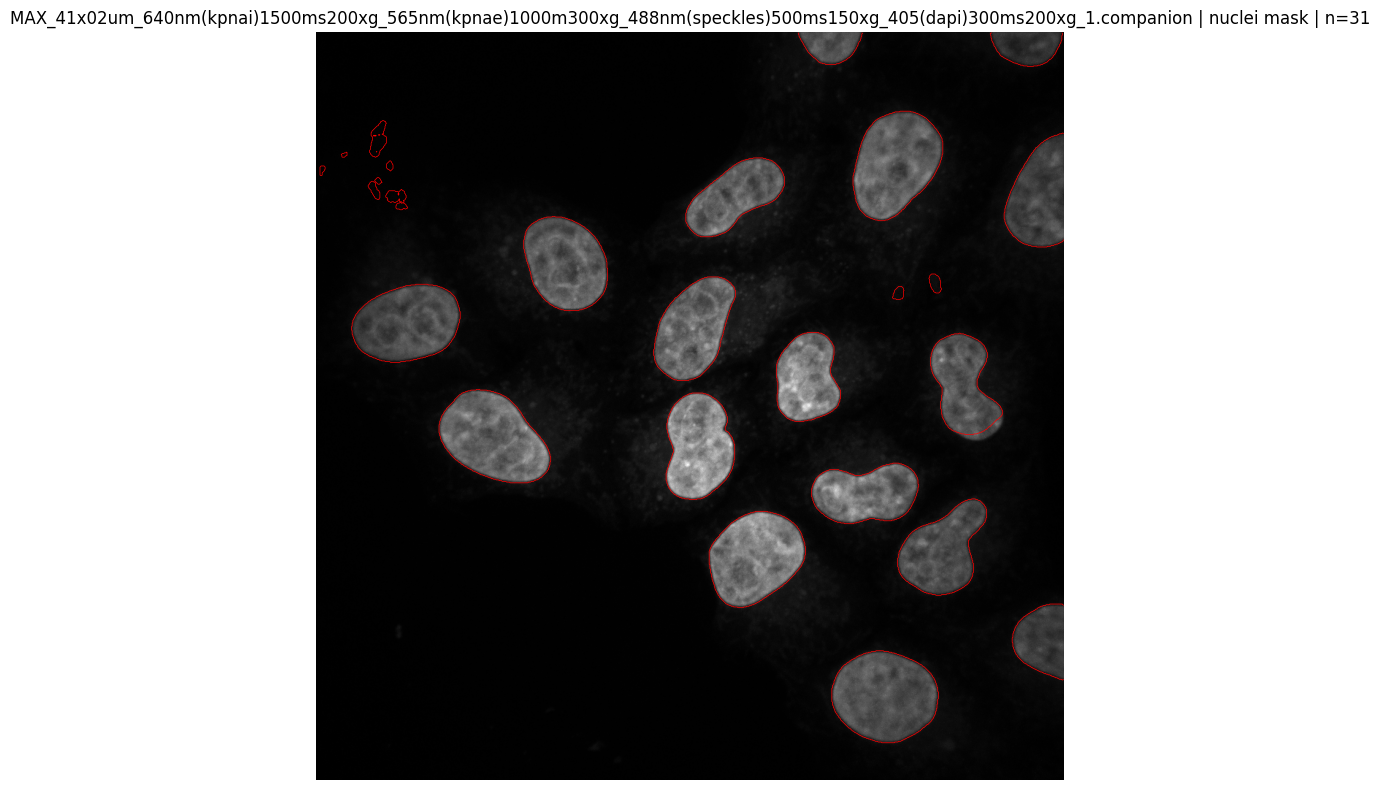

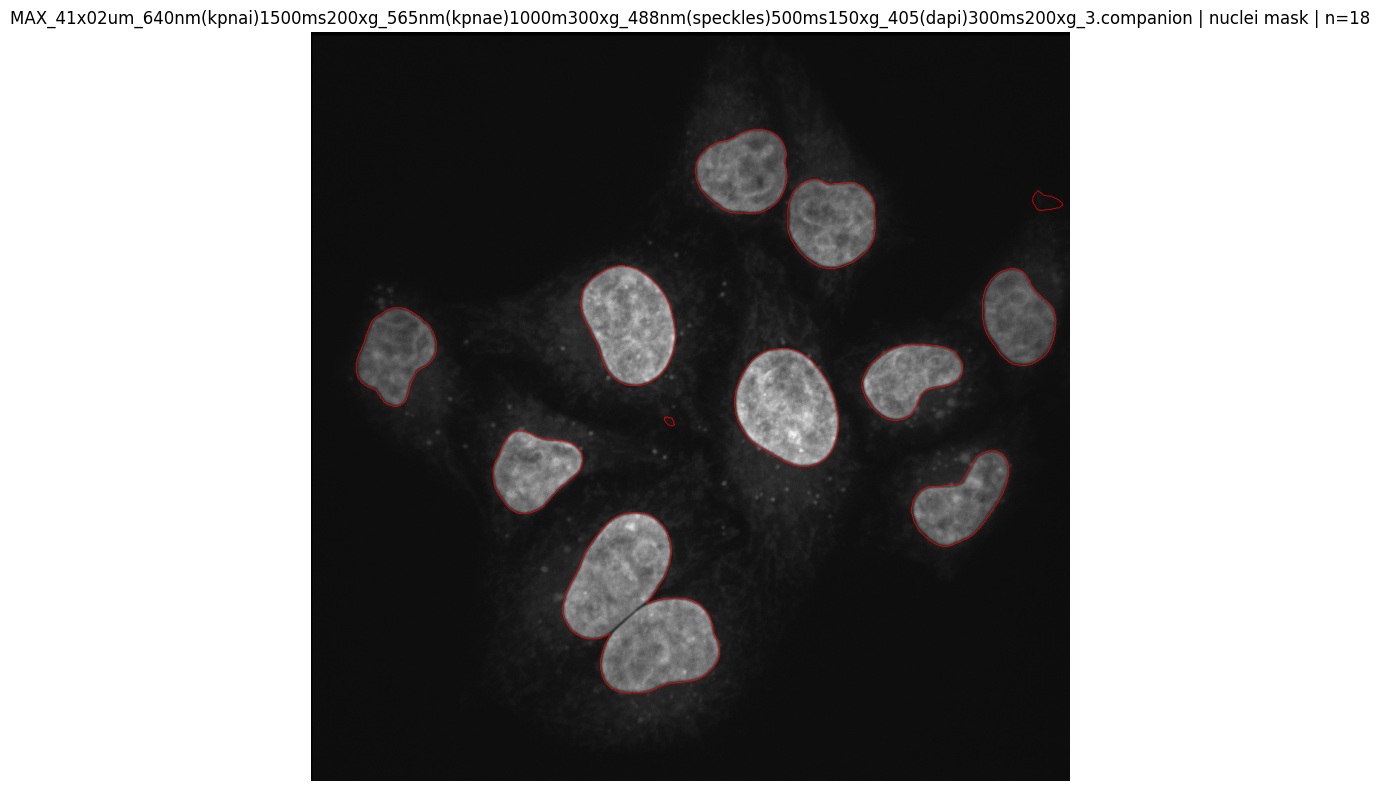

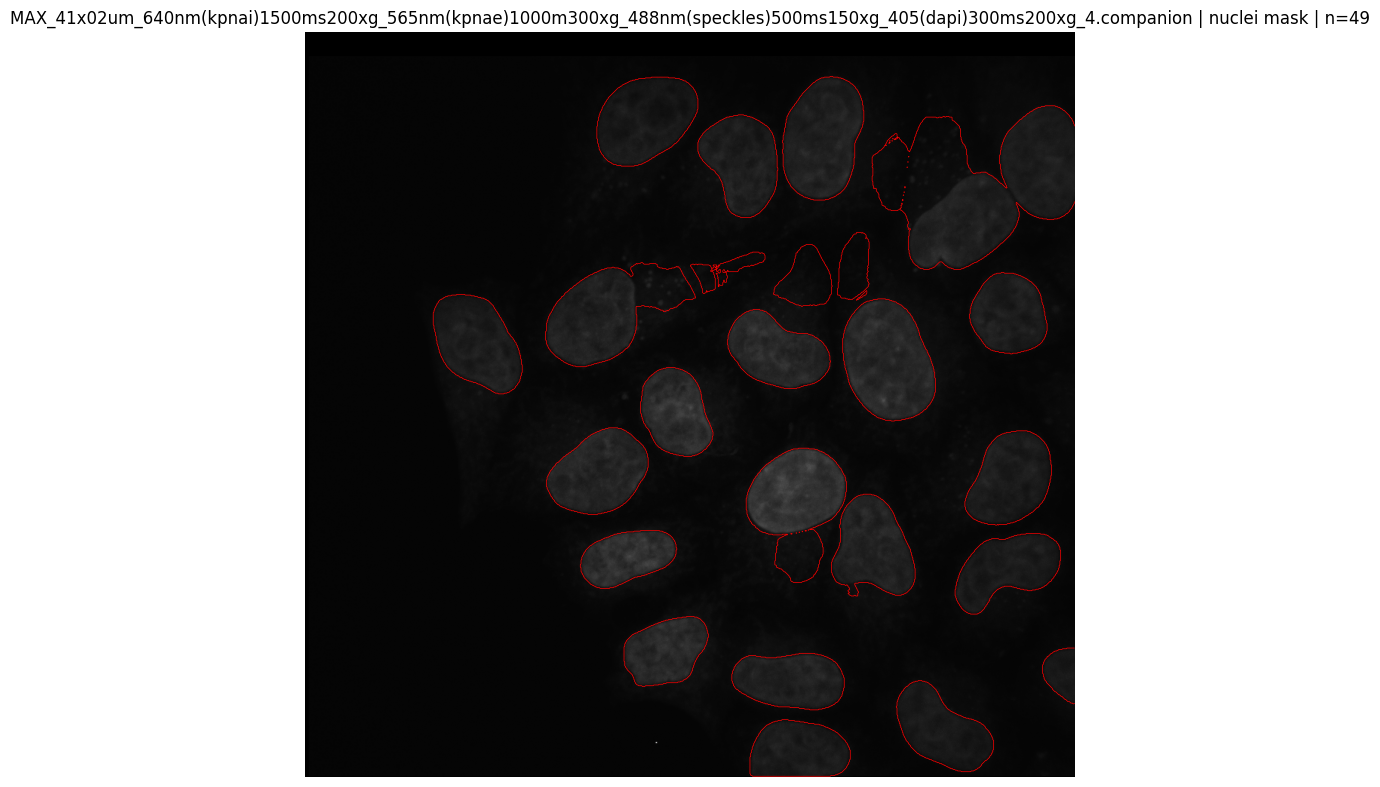

In [8]:
# Run cellpose nuclear segmentation and display mask outlines
nuclei_masks = {}

mask_dir = output_dir / "masks"
mask_dir.mkdir(exist_ok=True, parents=True)

for stem, data in tqdm(loaded_images.items()):
    dapi_img = data["dapi_img"]

    nuclei_mask = segment_nuclei_cpsam(dapi_img)
    nuclei_masks[stem] = nuclei_mask

    tiff.imwrite(
        mask_dir / f"{stem}_nuclei_cpsam_mask.tif",
        nuclei_mask.astype(np.uint16),
        compression="zlib"
    )
    # Display masks 
    plt.figure(figsize=(8, 8))
    plt.imshow(dapi_img, cmap="gray")
    plt.contour(nuclei_mask > 0, colors="red", linewidths=0.5)
    plt.title(f"{stem} | nuclei mask | n={int(nuclei_mask.max())}")
    plt.axis("off")
    plt.tight_layout()

print(f"Segmented nuclei for {len(nuclei_masks)} files")

  0%|          | 0/3 [00:00<?, ?it/s]

Thresholded speckles for 3 files


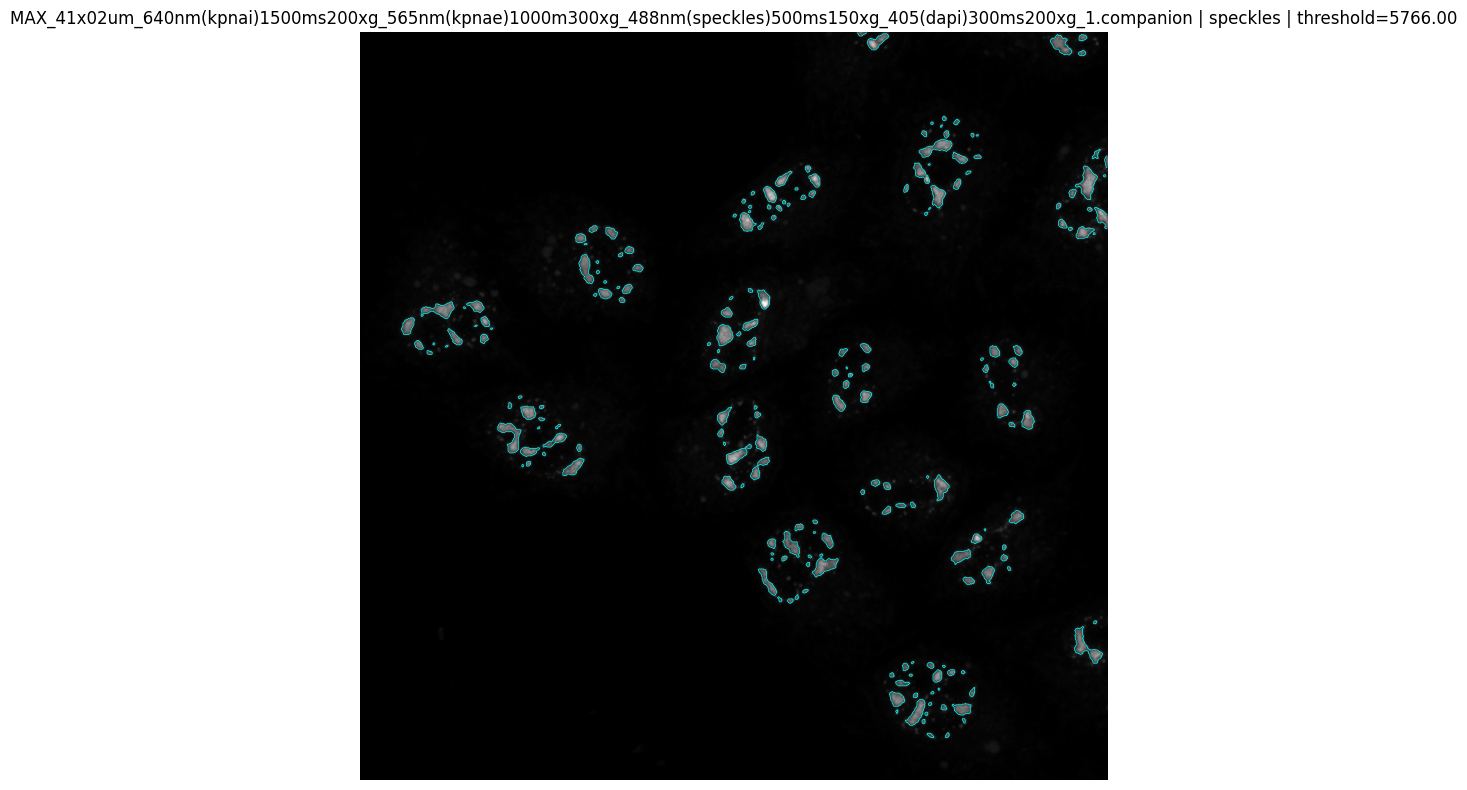

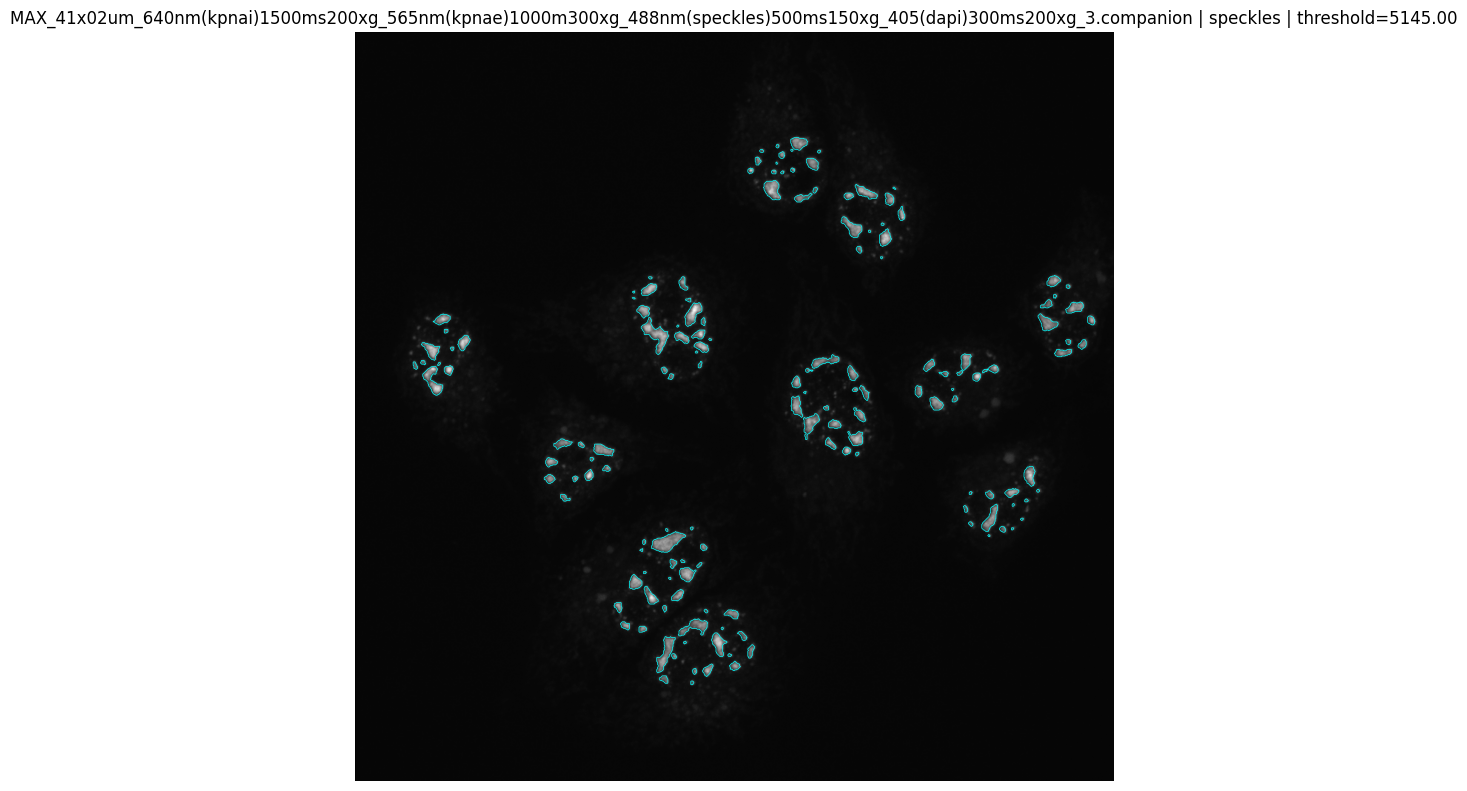

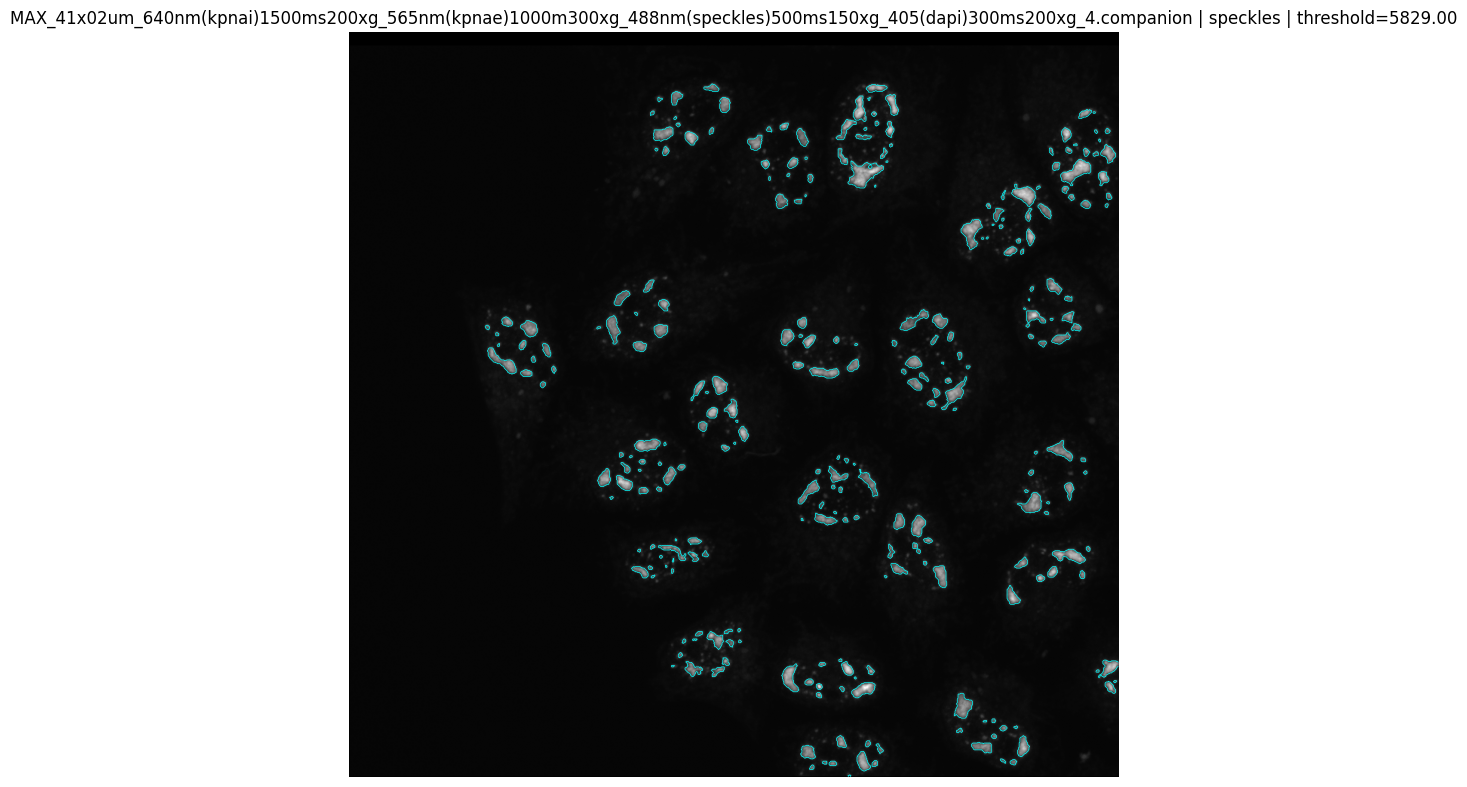

In [9]:
# Speckle thresholding mask and display mask outlines
speckle_masks = {}
speckle_thresholds = {}

for stem, data in tqdm(loaded_images.items()):
    speckle_img = data["speckle_img"]

    speckle_mask, spk_thresh = segment_speckles_otsu(speckle_img)

    speckle_masks[stem] = speckle_mask
    speckle_thresholds[stem] = spk_thresh

    tiff.imwrite(
        mask_dir / f"{stem}_speckles_mask.tif",
        speckle_mask.astype(np.uint8),
        compression="zlib"
    )
    # Display mask outlines
    plt.figure(figsize=(8, 8))
    plt.imshow(speckle_img, cmap="gray")
    plt.contour(speckle_mask, colors="cyan", linewidths=0.5)
    plt.title(f"{stem} | speckles | threshold={spk_thresh:.2f}")
    plt.axis("off")
    plt.tight_layout()

print(f"Thresholded speckles for {len(speckle_masks)} files")

## 2. Initial mask filtering

Speckle objects outside nuclear masks are removed. Nuclei without a sufficiently large enough overlapping speckle object (mitotic cells) are excluded before the filtered nuclear and speckle masks are saved.

In [10]:
# Create and size-filter speckle labels

min_speckle_object_area_px = min_speckle_size_px

speckle_label_masks = {}
speckle_props_tables = {}

for stem, speckle_mask in tqdm(speckle_masks.items()):
    nuclei_mask = nuclei_masks[stem]
    speckle_img = loaded_images[stem]["speckle_img"]

    # Separate extranuclear signal
    speckles_outside_nuclei = (
        speckle_mask.astype(bool) &
        (nuclei_mask == 0)
    )

    # Retain only speckle pixels inside nuclei
    speckles_inside_nuclei = (
        speckle_mask.astype(bool) &
        (nuclei_mask > 0)
    )

    # Label connected objects before size filtering
    unfiltered_labels = label(
        speckles_inside_nuclei,
        connectivity=2
    )

    # Measure object areas
    object_areas = np.bincount(unfiltered_labels.ravel())

    keep_speckle_ids = np.flatnonzero(
        object_areas >= min_speckle_object_area_px
    )
    keep_speckle_ids = keep_speckle_ids[
        keep_speckle_ids != 0
    ]

    # Retain sufficiently large speckle objects
    kept_speckles = np.isin(
        unfiltered_labels,
        keep_speckle_ids
    )

    removed_small_speckles = (
        (unfiltered_labels > 0) &
        ~kept_speckles
    )

    # Relabel retained objects consecutively
    speckle_labels = label(
        kept_speckles,
        connectivity=2
    )

    speckle_label_masks[stem] = speckle_labels

    props = regionprops_table(
        speckle_labels,
        intensity_image=speckle_img,
        properties=[
            "label",
            "area",
            "centroid",
            "mean_intensity",
            "max_intensity",
        ],
    )

    speckle_props_tables[stem] = pd.DataFrame(props)

    tiff.imwrite(
        mask_dir / f"{stem}_speckles_label_mask.tif",
        speckle_labels.astype(np.uint16),
        compression="zlib"
    )

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

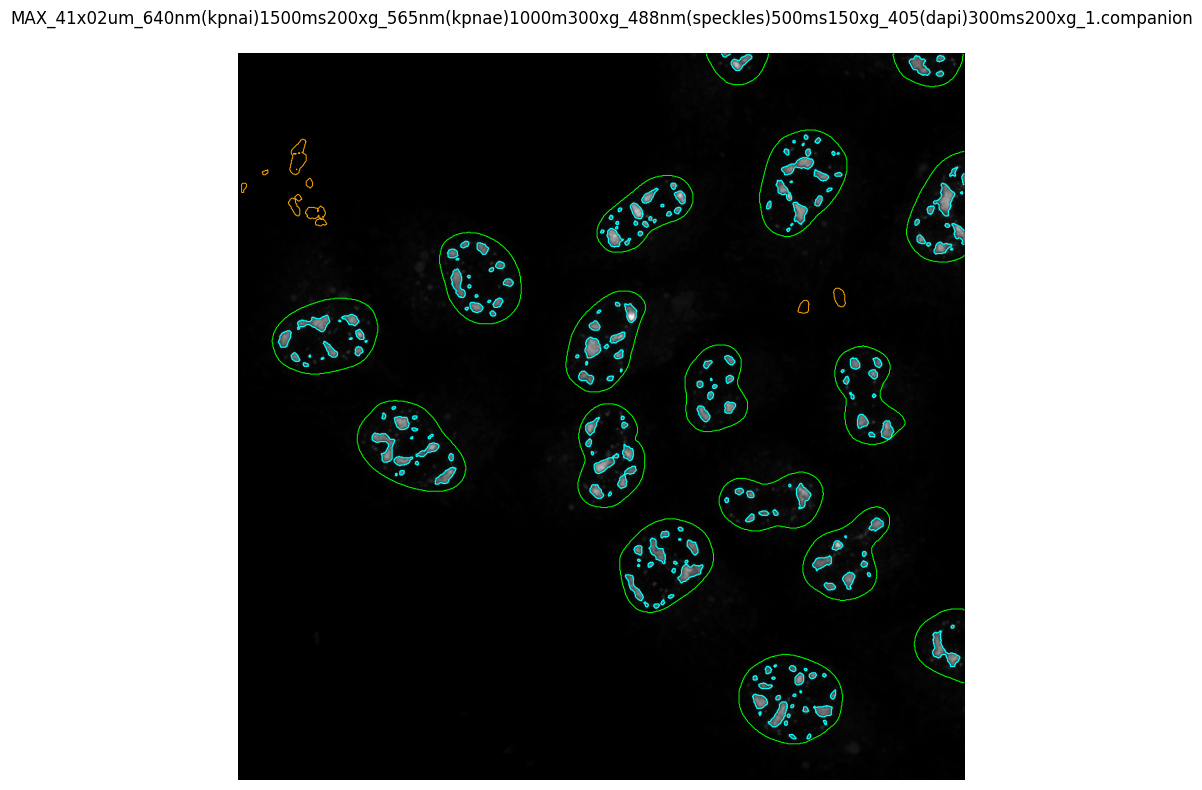

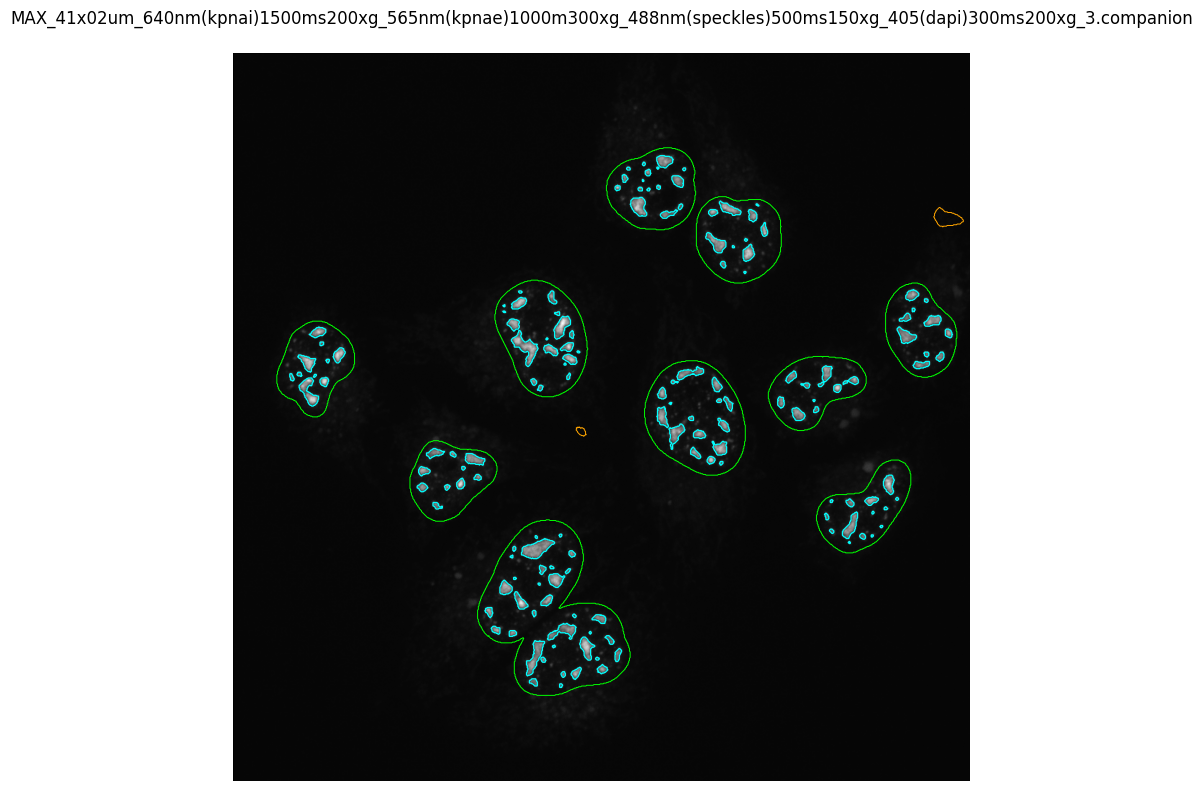

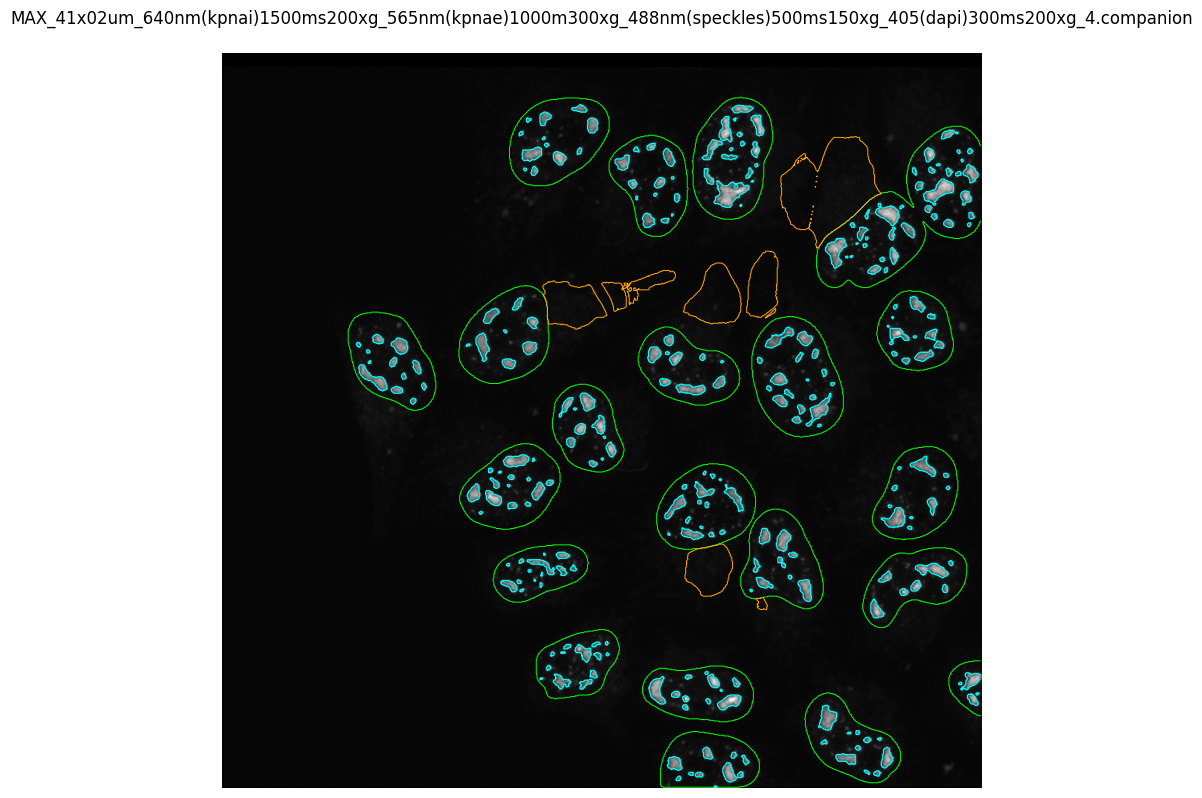

,file,n_nuclei_before,n_nuclei_after,n_speckles_before,n_speckles_after
0,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,31,17,203,203
1,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,18,12,150,150
2,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,49,23,266,266


In [11]:
# Filter masks: remove nuclear masks without speckles (mitotic) and remove speckle masks outside of nuclei (artifacts)
filtered_nuclei_masks = {}
filtered_speckle_label_masks = {}
filter_results = []

for stem in tqdm(loaded_images.keys()):

    nuclei_mask = nuclei_masks[stem]
    speckle_labels = speckle_label_masks[stem]
    speckle_img = loaded_images[stem]["speckle_img"]

    keep_nucleus_ids = []

    for nuc_id in np.unique(nuclei_mask):
        if nuc_id == 0:
            continue

        nucleus = nuclei_mask == nuc_id

        if np.any(speckle_labels[nucleus] > 0):
            keep_nucleus_ids.append(nuc_id)

    keep_nuclei_mask = np.isin(
        nuclei_mask,
        keep_nucleus_ids
    )

    filtered_nuclei = nuclei_mask.copy()
    filtered_nuclei[~keep_nuclei_mask] = 0

    filtered_speckles = speckle_labels.copy()
    filtered_speckles[filtered_nuclei == 0] = 0

    filtered_nuclei_masks[stem] = filtered_nuclei
    filtered_speckle_label_masks[stem] = filtered_speckles

    filter_results.append({
        "file": stem,
        "n_nuclei_before": int(nuclei_mask.max()),
        "n_nuclei_after": len(np.unique(filtered_nuclei)) - 1,
        "n_speckles_before": int(speckle_labels.max()),
        "n_speckles_after": len(np.unique(filtered_speckles)) - 1,
    })

    # Masks for QC display
    kept_nuclei = filtered_nuclei > 0
    removed_nuclei = (
        (nuclei_mask > 0) &
        (filtered_nuclei == 0)
    )

    kept_speckles = filtered_speckles > 0
    removed_speckles = (
        (speckle_labels > 0) &
        (filtered_speckles == 0)
    )

    # Display QC for this file
    plt.figure(figsize=(8, 8))
    plt.imshow(speckle_img, cmap="gray")

    # Kept nuclear masks
    if np.any(kept_nuclei):
        plt.contour(
            kept_nuclei,
            levels=[0.5],
            colors="lime",
            linewidths=0.7,
        )

    # Removed nuclear masks
    if np.any(removed_nuclei):
        plt.contour(
            removed_nuclei,
            levels=[0.5],
            colors="orange",
            linewidths=0.7,
        )

    # Kept speckle masks
    if np.any(kept_speckles):
        plt.contour(
            kept_speckles,
            levels=[0.5],
            colors="cyan",
            linewidths=0.9,
        )

    # Speckles removed with rejected nuclei
    if np.any(removed_speckles):
        plt.contour(
            removed_speckles,
            levels=[0.5],
            colors="red",
            linewidths=0.9,
        )

    plt.title(f"{stem}\n")

    plt.axis("off")
    plt.tight_layout()
    plt.show()
    plt.close()

filter_summary = pd.DataFrame(filter_results)
filter_summary

In [12]:
# save filtered masks
filtered_mask_dir = output_dir / "filtered_masks"
filtered_mask_dir.mkdir(exist_ok=True, parents=True)

for stem in tqdm(filtered_nuclei_masks.keys()):

    tiff.imwrite(
        filtered_mask_dir / f"{stem}_filtered_nuclei_mask.tif",
        filtered_nuclei_masks[stem].astype(np.uint16),
        compression="zlib"
    )

    tiff.imwrite(
        filtered_mask_dir / f"{stem}_filtered_speckle_labels.tif",
        filtered_speckle_label_masks[stem].astype(np.uint16),
        compression="zlib"
    )

print("Saved filtered masks.")

  0%|          | 0/3 [00:00<?, ?it/s]

Saved filtered masks.


## 3. Cell segmentation

Cells are segmented separately using blurred FISH signal together with the nuclear masks.

### 3.1 FISH image preparation

The selected FISH channel is blurred and background-subtracted before being combined with the nuclear mask for cell segmentation.

In [13]:
# Apply Gaussian blur to the selected FISH channel
blurred_fish_dir = output_dir / "blurred_fish"

blurred_fish_dir.mkdir(exist_ok=True, parents=True)

blurred_fish_images = {}

for stem, data in tqdm(loaded_images.items()):
    fish_img = data["fish_img"]

    blurred = gaussian_filter(
        fish_img.astype(float),
        sigma=fish_blur_sigma
    )

    blurred_fish_images[stem] = blurred

    tiff.imwrite(
        blurred_fish_dir /
        f"{stem}_C{fish_channel_index + 1}_blur_sigma{fish_blur_sigma}.tif",
        blurred.astype(np.float32),
        compression="zlib"
    )

print(
    f"Created blurred FISH images for "
    f"{len(blurred_fish_images)} files."
)

  0%|          | 0/3 [00:00<?, ?it/s]

Created blurred FISH images for 3 files.


In [14]:
# Background subtraction set-up 
blurred_dir = output_dir / "blurred_fish"
bgsub_dir = output_dir / "blurred_fish_rollingball_bgsub"
bgsub_dir.mkdir(exist_ok=True, parents=True)
blurred_bgsub_fish_images = {}

blurred_files = sorted(blurred_dir.glob("*.tif"))

In [15]:
# Rolling-ball background subtraction on already-saved blurred FISH images
for path in tqdm(blurred_files):

    stem = path.stem
    img = tiff.imread(path).astype(float)

    bg = rolling_ball(img, radius=rolling_ball_radius)

    img_bgsub = img - bg
    img_bgsub[img_bgsub < 0] = 0

    blurred_bgsub_fish_images[stem] = img_bgsub

    tiff.imwrite(
        bgsub_dir / f"{stem}_rollingball_r{rolling_ball_radius}_bgsub.tif",
        img_bgsub.astype(np.float32),
        compression="zlib"
    )

print("Finished rolling-ball background subtraction on blurred images.")

  0%|          | 0/3 [00:00<?, ?it/s]

Finished rolling-ball background subtraction on blurred images.


### 3.2 CPSAM cell segmentation

CPSAM is run on the prepared two-channel input. Cell masks that do not overlap a segmented nucleus are removed.

In [16]:
# Load saved filtered nuclei masks
filtered_mask_dir = output_dir / "filtered_masks"

nuclei_masks = {}

for path in sorted(filtered_mask_dir.glob("*_filtered_nuclei_mask.tif")):
    stem = path.name.replace("_filtered_nuclei_mask.tif", "")
    nuclei_masks[stem] = tiff.imread(path)

print(f"Loaded {len(nuclei_masks)} filtered nuclei masks")
print(list(nuclei_masks.keys())[:3])

Loaded 3 filtered nuclei masks
['MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_1.companion', 'MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_3.companion', 'MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_4.companion']


In [17]:
# Convert nuclear masks to 32 bit
nuclei_32_dir = output_dir / "nuclei_32bit"
nuclei_32_dir.mkdir(exist_ok=True, parents=True)

nuclei_32bit_paths = {}

for stem, nuclei_mask in tqdm(nuclei_masks.items()):

    nuclei_32 = nuclei_mask.astype(np.float32)

    out_path = nuclei_32_dir / f"{stem}_nuclei32.tif"
    tiff.imwrite(out_path, nuclei_32, compression="zlib")

    nuclei_32bit_paths[stem] = out_path

print("Saved 32-bit nuclei masks.")

  0%|          | 0/3 [00:00<?, ?it/s]

Saved 32-bit nuclei masks.


In [18]:
# Load blurred background-subtracted images (robust version, no param dependency)
blurred_bgsub_dir = output_dir / "blurred_fish_rollingball_bgsub"

blurred_bgsub_fish_images = {}

original_stems = list(nuclei_masks.keys())

for path in tqdm(sorted(blurred_bgsub_dir.glob("*.tif"))):

    fname = path.stem

    # find matching original stem
    match = None
    for s in original_stems:
        if fname.startswith(s):
            match = s
            break

    if match is None:
        print(f"Could not match: {fname}")
        continue

    img = tiff.imread(path).astype(float)
    blurred_bgsub_fish_images[match] = img

print(f"Loaded {len(blurred_bgsub_fish_images)} blurred/bgsub images")

  0%|          | 0/3 [00:00<?, ?it/s]

Loaded 3 blurred/bgsub images


In [19]:
# Overlay nuclear masks and blurred, bg-sub FISH image
cpsam_input_dir = output_dir / "cpsam_input"
cpsam_input_dir.mkdir(exist_ok=True, parents=True)

cpsam_input_paths = {}

for stem in tqdm(nuclei_masks.keys()):

    if stem not in blurred_bgsub_fish_images:
        print(f"Skipping {stem}: no blurred/bgsub FISH image found")
        continue

    fish = blurred_bgsub_fish_images[stem]
    nuclei = tiff.imread(nuclei_32bit_paths[stem])

    # normalize both
    fish_norm = (fish - fish.min()) / (fish.max() - fish.min() + 1e-8)
    nuclei_norm = (nuclei > 0).astype(np.float32)

    stack = np.stack([fish_norm, nuclei_norm], axis=0).astype(np.float32)

    out_path = cpsam_input_dir / f"{stem}_cpsam_input.tif"
    tiff.imwrite(out_path, stack, compression="zlib")

    cpsam_input_paths[stem] = out_path

print(f"Created {len(cpsam_input_paths)} CPSAM input stacks.")

  0%|          | 0/3 [00:00<?, ?it/s]

Created 3 CPSAM input stacks.


In [20]:
# Load cellpose
from cellpose import models

model = models.CellposeModel(
    gpu=True,
    pretrained_model=cell_segmentation_model
)

print("CPSAM model loaded")

CPSAM model loaded


In [21]:
# Run cellpose 
cellpose_masks = {}

cpsam_mask_dir = output_dir / "cpsam_cell_masks"
cpsam_mask_dir.mkdir(exist_ok=True, parents=True)

for stem, path in tqdm(cpsam_input_paths.items()):

    img = tiff.imread(path)  # shape (2, Y, X)

    masks, flows, styles = model.eval(
        img,
        diameter=cpsam_diameter,
        channels=[1, 2],  # 1=fish, 2=nuclei
        flow_threshold=cpsam_flow_threshold,
        cellprob_threshold=cpsam_cellprob_threshold
    )

    cellpose_masks[stem] = masks

    tiff.imwrite(
        cpsam_mask_dir / f"{stem}_cpsam_cells.tif",
        masks.astype(np.uint16),
        compression="zlib"
    )

print("Ran CPSAM segmentation.")

  0%|          | 0/3 [00:00<?, ?it/s]

channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


Ran CPSAM segmentation.


  0%|          | 0/3 [00:00<?, ?it/s]

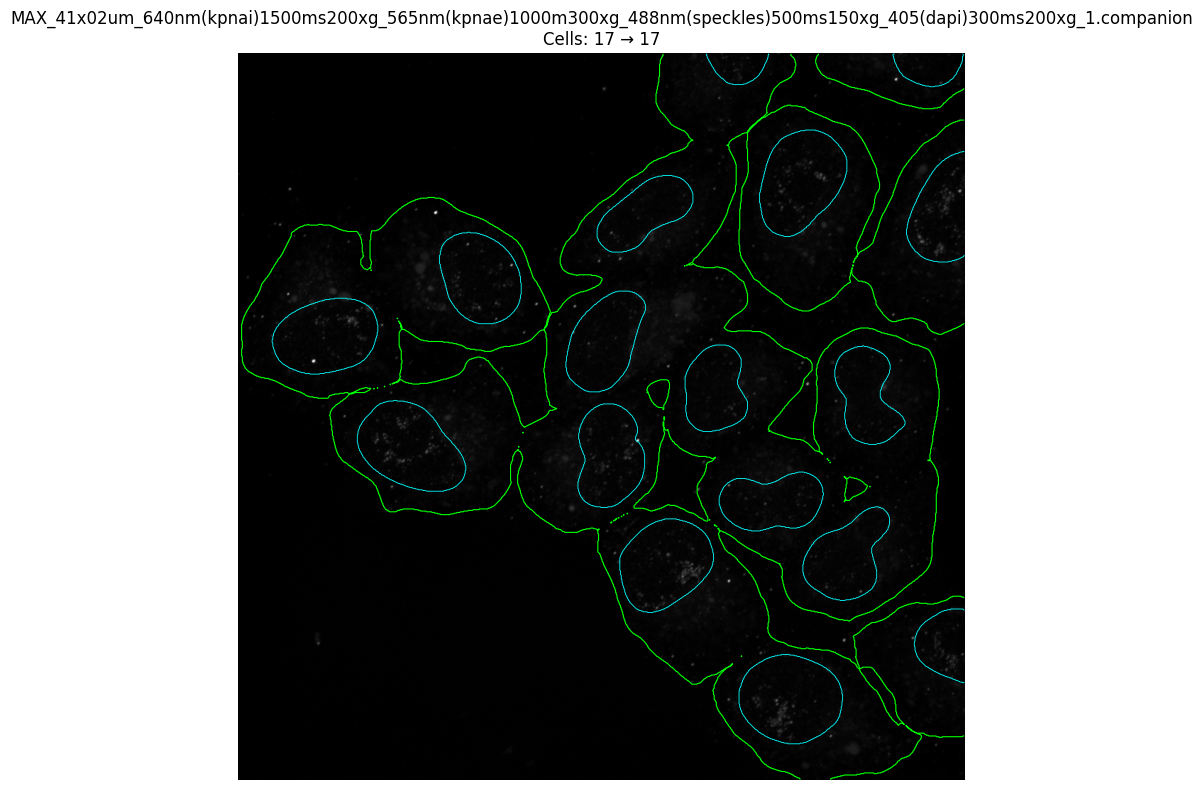

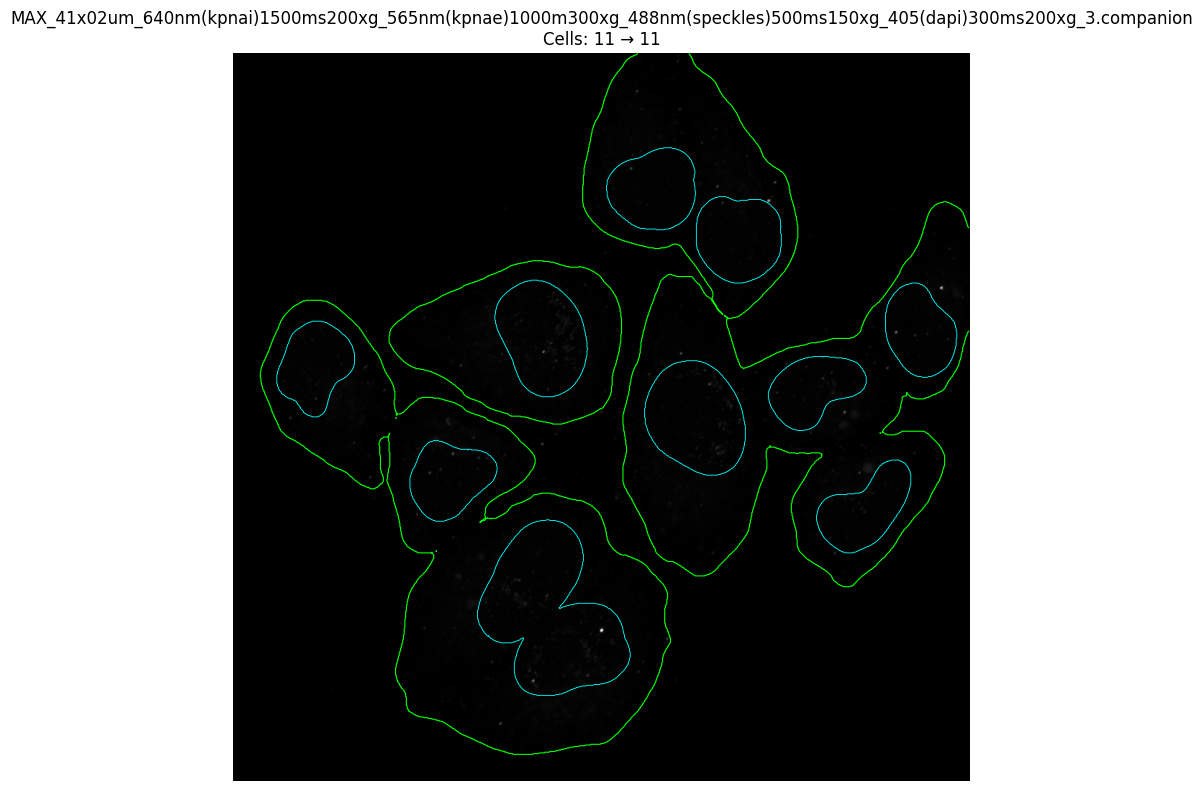

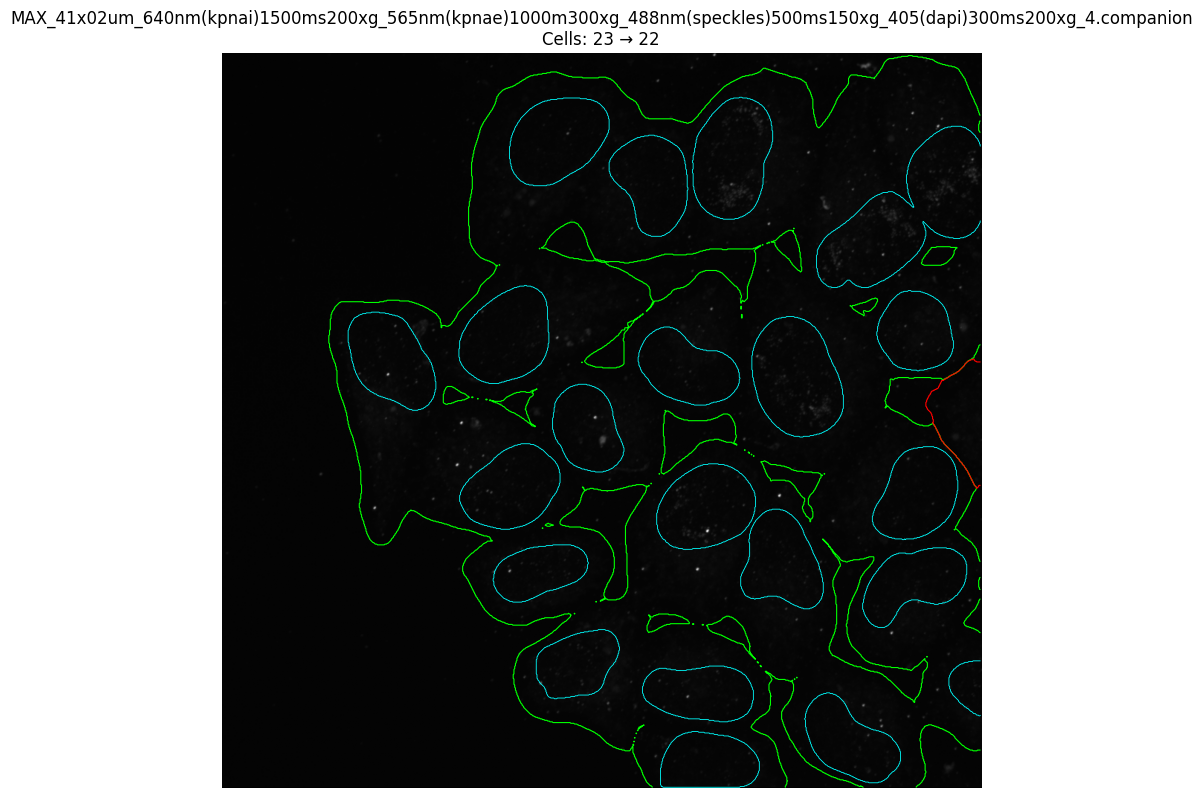

,file,cells_before,cells_after
0,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,17,17
1,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,11,11
2,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,23,22


In [22]:
# Filter cells without nucleus
filtered_cell_masks = {}

filtered_dir = output_dir / "cpsam_cells_filtered"
filtered_dir.mkdir(exist_ok=True, parents=True)

filter_results = []

for stem in tqdm(cellpose_masks.keys()):

    if stem not in nuclei_masks:
        print(f"Skipping {stem}: no nuclei mask")
        continue

    cells = cellpose_masks[stem]
    nuclei = nuclei_masks[stem]
    fish_img = loaded_images[stem]["fish_img"]

    keep_ids = []

    for cid in np.unique(cells):
        if cid == 0:
            continue

        cell = cells == cid

        # Keep only cells overlapping at least one nucleus
        if np.any(nuclei[cell] > 0):
            keep_ids.append(cid)

    keep_cell_mask = np.isin(cells, keep_ids)

    filtered = cells.copy()
    filtered[~keep_cell_mask] = 0

    filtered_cell_masks[stem] = filtered

    tiff.imwrite(
        filtered_dir / f"{stem}_cpsam_cells_filtered.tif",
        filtered.astype(np.uint16),
        compression="zlib"
    )

    cells_before = len(np.unique(cells)) - 1
    cells_after = len(np.unique(filtered)) - 1

    filter_results.append({
        "file": stem,
        "cells_before": int(cells_before),
        "cells_after": int(cells_after),
    })

    # Masks for QC display
    kept_cells = filtered > 0
    removed_cells = (cells > 0) & (filtered == 0)

    # Display QC in notebook
    plt.figure(figsize=(8, 8))
    plt.imshow(fish_img, cmap="gray")

    if np.any(kept_cells):
        plt.contour(
            kept_cells,
            levels=[0.5],
            colors="lime",
            linewidths=0.8,
        )

    if np.any(removed_cells):
        plt.contour(
            removed_cells,
            levels=[0.5],
            colors="red",
            linewidths=0.8,
        )

    if np.any(nuclei > 0):
        plt.contour(
            nuclei > 0,
            levels=[0.5],
            colors="cyan",
            linewidths=0.6,
        )

    plt.title(
        f"{stem}\n"
        f"Cells: {cells_before} → {cells_after}"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    plt.close()

filter_summary = pd.DataFrame(filter_results)
filter_summary.to_csv(
    output_dir / "cpsam_filter_summary.csv",
    index=False
)

filter_summary

## 4. Quantification

Final nuclear, speckle and cell masks are reloaded from disk and matched to the raw images by filename stem. The set-up cell on top still has to be run to define directories and load files. Cells are linked to the nucleus with the largest overlap. Measurements are collected separately for cell, cytoplasm, nucleus, speckles and nucleus without speckles.

Background is estimated per image from pixels outside segmented cells and nuclei. Condition names are not assigned by this code; the analysis operates on the files present in the selected input folder and propagates their file stems into the output tables.

### 4.1 Data loading and size filtering

In [23]:
# FISH channels to quantify
# microscopy C1/C2/C3/C4 -> Python 0/1/2/3

fish_channels = {
    "exonic": 1,    # C2
    "intronic": 0,  # C1; comment out for for BRD4 smFISH (only exons stained)
}

print(f"Selected {len(tif_files)} files")

Selected 3 files


In [24]:
# Helpers

def load_raw_channel(path, channel_index):
    arr = tiff.imread(path)
    cyx, axes = to_cyx_max_projection(arr)
    if channel_index >= cyx.shape[0]:
        raise IndexError(
            f"Requested channel index {channel_index}, but image has shape {cyx.shape}"
        )
    return cyx[channel_index].astype(float), axes


def load_mask_dict(mask_dir, suffix):
    masks = {}
    paths = sorted(mask_dir.glob(f"*{suffix}.tif"))

    for path in paths:
        stem = path.name.replace(f"{suffix}.tif", "")
        masks[stem] = tiff.imread(path)

    print(f"Loaded {len(masks)} masks from {mask_dir} with suffix {suffix}")
    return masks


def measure_region_values(img, mask_bool, background):
    values = img[mask_bool]

    if values.size == 0:
        return {
            "area_px": 0,
            "mean_raw": np.nan,
            "median_raw": np.nan,
            "sum_raw": np.nan,
            "mean_bgcorr": np.nan,
            "median_bgcorr": np.nan,
            "sum_bgcorr": np.nan,
        }

    corrected = values - background
    corrected[corrected < 0] = 0

    return {
        "area_px": int(values.size),
        "mean_raw": float(np.mean(values)),
        "median_raw": float(np.median(values)),
        "sum_raw": float(np.sum(values)),
        "mean_bgcorr": float(np.mean(corrected)),
        "median_bgcorr": float(np.median(corrected)),
        "sum_bgcorr": float(np.sum(corrected)),
    }

In [25]:
# Reload final masks from disk

nuclei_masks = load_mask_dict(
    filtered_mask_dir,
    "_filtered_nuclei_mask"
)

speckle_masks = load_mask_dict(
    filtered_mask_dir,
    "_filtered_speckle_labels"
)

filtered_cell_dir = output_dir / "cpsam_cells_filtered"

cell_masks = load_mask_dict(
    filtered_cell_dir,
    "_cpsam_cells_filtered"
)

common_stems = sorted(
    set(nuclei_masks.keys())
    & set(speckle_masks.keys())
    & set(cell_masks.keys())
)

print("Common files:", len(common_stems))
print(common_stems[:3])

Loaded 3 masks from /Users/niko/Desktop/print_and_trash/1_CTRL/segmentations_clean/filtered_masks with suffix _filtered_nuclei_mask
Loaded 3 masks from /Users/niko/Desktop/print_and_trash/1_CTRL/segmentations_clean/filtered_masks with suffix _filtered_speckle_labels
Loaded 3 masks from /Users/niko/Desktop/print_and_trash/1_CTRL/segmentations_clean/cpsam_cells_filtered with suffix _cpsam_cells_filtered
Common files: 3
['MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_1.companion', 'MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_3.companion', 'MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_4.companion']


In [26]:
# Compute global median cell and nucleus sizes from all linked cell-nucleus pairs
cell_areas_all = []
nucleus_areas_all = []

for stem in common_stems:
    nuclei = nuclei_masks[stem]
    cells = cell_masks[stem]

    for cell_id in np.unique(cells):
        if cell_id == 0:
            continue

        cell_region = cells == cell_id
        cell_area = int(cell_region.sum())

        overlapping_nuc_ids = np.unique(nuclei[cell_region])
        overlapping_nuc_ids = overlapping_nuc_ids[overlapping_nuc_ids != 0]

        if len(overlapping_nuc_ids) == 0:
            continue

        # assign largest-overlap nucleus to this cell
        best_nuc_id = None
        best_overlap = 0

        for nuc_id in overlapping_nuc_ids:
            overlap = int(np.sum(cell_region & (nuclei == nuc_id)))
            if overlap > best_overlap:
                best_overlap = overlap
                best_nuc_id = nuc_id

        nuc_area = int(np.sum(nuclei == best_nuc_id))

        cell_areas_all.append(cell_area)
        nucleus_areas_all.append(nuc_area)

median_cell_area = np.median(cell_areas_all)
median_nucleus_area = np.median(nucleus_areas_all)

print("Median cell area:", median_cell_area)
print("Median nucleus area:", median_nucleus_area)

Median cell area: 30586.5
Median nucleus area: 10092.0


In [27]:
# Optional: filter cells/nuclei that are too small or large (segmentation artifacts or on the edge of image)
# Use None to disable

# Define x bounds
min_cell_area_px = median_cell_area / 3.5
max_cell_area_px = median_cell_area * 3.5

min_nucleus_area_px = median_nucleus_area / 3.5
max_nucleus_area_px = median_nucleus_area * 3.5

print("Median cell area:", median_cell_area)
print("Cell area bounds:", min_cell_area_px, "to", max_cell_area_px)
print("Median nucleus area:", median_nucleus_area)
print("Nucleus area bounds:", min_nucleus_area_px, "to", max_nucleus_area_px)


Median cell area: 30586.5
Cell area bounds: 8739.0 to 107052.75
Median nucleus area: 10092.0
Nucleus area bounds: 2883.4285714285716 to 35322.0


In [28]:
# Filter cells and save log file
analysis_dir = output_dir / "analysis"
analysis_dir.mkdir(exist_ok=True, parents=True)

filtered_nuclei_for_analysis = {}
filtered_speckles_for_analysis = {}
filtered_cells_for_analysis = {}

filter_log = []

for stem in tqdm(common_stems, desc="Filtering cells/nuclei by size"):

    nuclei = nuclei_masks[stem].copy()
    speckles = speckle_label_masks[stem].copy()
    cells = cell_masks[stem].copy()

    keep_cell_ids = []
    keep_nucleus_ids = []

    for cell_id in np.unique(cells):
        if cell_id == 0:
            continue

        cell_region = cells == cell_id
        cell_area = int(cell_region.sum())

        overlapping_nuc_ids = np.unique(nuclei[cell_region])
        overlapping_nuc_ids = overlapping_nuc_ids[overlapping_nuc_ids != 0]

        if len(overlapping_nuc_ids) == 0:
            filter_log.append({
                "file": stem,
                "cell_id": int(cell_id),
                "linked_nucleus_id": None,
                "cell_area_px": cell_area,
                "nucleus_area_px": None,
                "nucleus_overlap_px": 0,
                "kept": False,
                "reason": "no_overlapping_nucleus",
            })
            continue

        # assign largest-overlap nucleus to this cell
        best_nuc_id = None
        best_overlap = 0

        for nuc_id in overlapping_nuc_ids:
            overlap = int(np.sum(cell_region & (nuclei == nuc_id)))
            if overlap > best_overlap:
                best_overlap = overlap
                best_nuc_id = nuc_id

        nuc_area = int(np.sum(nuclei == best_nuc_id))

        keep = True
        reasons = []

        if cell_area < min_cell_area_px:
            keep = False
            reasons.append("cell_too_small")

        if cell_area > max_cell_area_px:
            keep = False
            reasons.append("cell_too_large")

        if nuc_area < min_nucleus_area_px:
            keep = False
            reasons.append("nucleus_too_small")

        if nuc_area > max_nucleus_area_px:
            keep = False
            reasons.append("nucleus_too_large")

        if keep:
            keep_cell_ids.append(cell_id)
            keep_nucleus_ids.append(best_nuc_id)
            reasons.append("kept")

        filter_log.append({
            "file": stem,
            "cell_id": int(cell_id),
            "linked_nucleus_id": int(best_nuc_id),
            "cell_area_px": cell_area,
            "nucleus_area_px": nuc_area,
            "nucleus_overlap_px": int(best_overlap),
            "kept": bool(keep),
            "reason": ";".join(reasons),
        })

    # Filter cells
    cells_filtered = cells.copy()
    cells_filtered[~np.isin(cells_filtered, keep_cell_ids)] = 0

    # Filter nuclei: keep only nuclei linked to kept cells
    nuclei_filtered = nuclei.copy()
    nuclei_filtered[~np.isin(nuclei_filtered, keep_nucleus_ids)] = 0

    # Also remove nuclei outside kept cells
    nuclei_filtered[cells_filtered == 0] = 0

    # Filter speckles: keep only speckles inside kept nuclei
    speckles_filtered = speckles.copy()
    speckles_filtered[nuclei_filtered == 0] = 0

    filtered_cells_for_analysis[stem] = cells_filtered
    filtered_nuclei_for_analysis[stem] = nuclei_filtered
    filtered_speckles_for_analysis[stem] = speckles_filtered

# save filter log

filter_log_df = pd.DataFrame(filter_log)
filter_log_df.to_csv(analysis_dir / "median_size_filter_log.csv", index=False)

print("Saved filter log to:")
print(analysis_dir / "median_size_filter_log.csv")

print("Cells before filtering:", len(filter_log_df))
print("Cells kept:", int(filter_log_df["kept"].sum()))
print("Cells removed:", int((~filter_log_df["kept"]).sum()))

filter_log_df.head()

Filtering cells/nuclei by size:   0%|          | 0/3 [00:00<?, ?it/s]

Saved filter log to:
/Users/niko/Desktop/print_and_trash/1_CTRL/segmentations_clean/analysis/median_size_filter_log.csv
Cells before filtering: 50
Cells kept: 48
Cells removed: 2


,file,cell_id,linked_nucleus_id,cell_area_px,nucleus_area_px,nucleus_overlap_px,kept,reason
0,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,1,1,18783,2832,2832,False,nucleus_too_small
1,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,2,2,12169,3573,3573,True,kept
2,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,3,3,42864,13365,13365,True,kept
3,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,4,5,30828,9451,9451,True,kept
4,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,5,9,30338,8575,8575,True,kept


In [29]:
# Quantification channel loop
measurement_rows = []

for stem in tqdm(common_stems):

    raw_matches = [p for p in tif_files if p.stem == stem]

    if len(raw_matches) != 1:
        print(
            f"Skipping {stem}: found "
            f"{len(raw_matches)} raw image matches"
        )
        continue

    raw_path = raw_matches[0]

    # Load already projected CYX image once
    cyx = tiff.imread(raw_path)

    try:
        cyx = validate_cyx_projection(
            cyx,
            expected_channels=channels
        )
    except ValueError as error:
        print(f"Skipping {stem}: {error}")
        continue

    nuclei = filtered_nuclei_for_analysis[stem]
    speckles = filtered_speckles_for_analysis[stem]
    cells = filtered_cells_for_analysis[stem]

    # Check that image and masks have matching dimensions
    if cyx.shape[1:] != nuclei.shape:
        print(
            f"Skipping {stem}: image shape {cyx.shape[1:]} "
            f"does not match mask shape {nuclei.shape}"
        )
        continue

    for fish_name, channel_index in fish_channels.items():

        if channel_index >= cyx.shape[0]:
            print(
                f"Skipping {stem}, {fish_name}: "
                f"channel {channel_index} is unavailable"
            )
            continue

        fish_img = cyx[channel_index].astype(float)

        background_mask = (
            (cells == 0) &
            (nuclei == 0)
        )

        if np.any(background_mask):
            background = float(
                np.median(fish_img[background_mask])
            )
        else:
            background = float(
                np.percentile(fish_img, 5)
            )

        for cell_id in np.unique(cells):
            if cell_id == 0:
                continue

            cell_region = cells == cell_id

            overlapping_nuc_ids = np.unique(
                nuclei[cell_region]
            )
            overlapping_nuc_ids = overlapping_nuc_ids[
                overlapping_nuc_ids != 0
            ]

            if len(overlapping_nuc_ids) == 0:
                continue

            best_nuc_id = None
            best_overlap = 0

            for nuc_id in overlapping_nuc_ids:
                overlap = int(
                    np.sum(
                        cell_region &
                        (nuclei == nuc_id)
                    )
                )

                if overlap > best_overlap:
                    best_overlap = overlap
                    best_nuc_id = nuc_id

            nucleus_region = nuclei == best_nuc_id
            speckle_region = (
                (speckles > 0) &
                nucleus_region
            )

            nuclear_without_speckles_region = (
                nucleus_region &
                ~speckle_region
            )

            cytoplasm_region = (
                cell_region &
                (nuclei == 0)
            )

            region_masks = {
                "cell": cell_region,
                "cytoplasm": cytoplasm_region,
                "nucleus": nucleus_region,
                "speckles": speckle_region,
                "nucleus_without_speckles":
                    nuclear_without_speckles_region,
            }

            speckle_ids = np.unique(
                speckles[speckle_region]
            )
            speckle_ids = speckle_ids[
                speckle_ids != 0
            ]

            speckle_ids_str = ";".join(
                map(str, speckle_ids.tolist())
            )

            for region_name, region_mask in region_masks.items():

                m = measure_region_values(
                    fish_img,
                    region_mask,
                    background=background
                )

                measurement_rows.append({
                    "file": stem,
                    "raw_image_file": raw_path.name,
                    "fish_modality": fish_name,
                    "fish_channel_index_python":
                        channel_index,
                    "fish_channel_microscopy":
                        f"C{channel_index + 1}",
                    "cell_id": int(cell_id),
                    "nucleus_id": int(best_nuc_id),
                    "speckle_ids_in_nucleus":
                        speckle_ids_str,
                    "region": region_name,
                    "background_median_noncell_nonnuclear":
                        background,
                    "cell_nucleus_overlap_px":
                        int(best_overlap),
                    **m,
                })

measurements = pd.DataFrame(measurement_rows)

out_csv = (
    analysis_dir /
    "smfish_intensity_measurements_by_mask.csv"
)

measurements.to_csv(out_csv, index=False)

measurements.head()

  0%|          | 0/3 [00:00<?, ?it/s]

,file,raw_image_file,fish_modality,fish_channel_index_python,fish_channel_microscopy,cell_id,nucleus_id,speckle_ids_in_nucleus,region,background_median_noncell_nonnuclear,cell_nucleus_overlap_px,area_px,mean_raw,median_raw,sum_raw,mean_bgcorr,median_bgcorr,sum_bgcorr
0,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,exonic,1,C2,2,2,3;4;5,cell,1053.0,3573,12169,1816.477114,1535.0,22104710.0,769.918481,482.0,9369138.0
1,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,exonic,1,C2,2,2,3;4;5,cytoplasm,1053.0,3573,8596,1835.330619,1540.0,15776502.0,791.419614,487.0,6803043.0
2,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,exonic,1,C2,2,2,3;4;5,nucleus,1053.0,3573,3573,1771.118948,1528.0,6328208.0,718.190596,475.0,2566095.0
3,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,exonic,1,C2,2,2,3;4;5,speckles,1053.0,3573,561,2017.456328,1821.0,1131793.0,964.456328,768.0,541060.0
4,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,exonic,1,C2,2,2,3;4;5,nucleus_without_speckles,1053.0,3573,3012,1725.237384,1468.0,5196415.0,672.322377,415.0,2025035.0


In [30]:
# Wide format summary (per cell, per fish channel)
wide = measurements.pivot_table(
    index=[
        "file",
        "raw_image_file",
        "fish_modality",
        "fish_channel_index_python",
        "fish_channel_microscopy",
        "cell_id",
        "nucleus_id",
        "speckle_ids_in_nucleus",
        "background_median_noncell_nonnuclear",
    ],
    columns="region",
    values=[
        "area_px",
        "mean_raw",
        "median_raw",
        "sum_raw",
        "mean_bgcorr",
        "median_bgcorr",
        "sum_bgcorr",
    ],
    aggfunc="first"
)

wide.columns = [f"{metric}_{region}" for metric, region in wide.columns]
wide = wide.reset_index()

wide_csv = analysis_dir / "smfish_intensity_measurements_by_cell_wide.csv"
wide.to_csv(wide_csv, index=False)

print("Saved:", wide_csv)
wide.head()

Saved: /Users/niko/Desktop/print_and_trash/1_CTRL/segmentations_clean/analysis/smfish_intensity_measurements_by_cell_wide.csv


,file,raw_image_file,fish_modality,fish_channel_index_python,fish_channel_microscopy,cell_id,nucleus_id,speckle_ids_in_nucleus,background_median_noncell_nonnuclear,area_px_cell,...,sum_bgcorr_cell,sum_bgcorr_cytoplasm,sum_bgcorr_nucleus,sum_bgcorr_nucleus_without_speckles,sum_bgcorr_speckles,sum_raw_cell,sum_raw_cytoplasm,sum_raw_nucleus,sum_raw_nucleus_without_speckles,sum_raw_speckles
0,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,exonic,1,C2,2,2,3;4;5,1053.0,12169,...,9369138.0,6803043.0,2566095.0,2025035.0,541060.0,22104710.0,15776502.0,6328208.0,5196415.0,1131793.0
1,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,exonic,1,C2,3,3,6;7;8;9;10;11;12;13;14;16;17;19;20;24;27;28;29...,1053.0,42864,...,39974376.0,24215019.0,15759357.0,10720400.0,5038957.0,85048170.0,55215468.0,29832702.0,22966790.0,6865912.0
2,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,exonic,1,C2,4,5,15;18;22;26;32;39;44;45;51;54;56;57,1053.0,30828,...,33620682.0,16867761.0,16752921.0,10041850.0,6711071.0,66033674.0,39328850.0,26704824.0,18346861.0,8357963.0
3,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,exonic,1,C2,5,9,21;23;25;30;31;33;34;35;36;37;38;40;41;42;46;4...,1053.0,30338,...,28764856.0,19231267.0,9533589.0,7415221.0,2118368.0,60623726.0,42060662.0,18563064.0,14974708.0,3588356.0
4,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,exonic,1,C2,6,18,53;55;58;59;60;61;62;63;64;65;66;67;68;69;72;74,1053.0,38932,...,39905806.0,26391606.0,13514200.0,9653433.0,3860767.0,80773158.0,55231592.0,25541566.0,20152896.0,5388670.0


### 4.1 Size filtering and manual QC

Cell and nucleus size limits are calculated from the linked cell-nucleus population. Rows marked `FALSE` in the `kept` column are excluded from the final wide-format table. Poor segmentation masks were noted down in the log file manually with `FALSE` in the `kept` column and `bad_segmentation` in the `reason` column.

In [31]:
# To filter out poorly segmented cells, edit the median_size_filter_log
# In the 'kept' column enter FALSE and in the 'reason' column enter bad_segmentation
# Save the edited log file in the same folder under the same name
# Load manually edited filter table and exclude cells where kept == FALSE

filter_csv = analysis_dir / "median_size_filter_log.csv"

for enc in ["utf-8-sig", "utf-8", "latin1", "cp1252"]:
    try:
        manual_filter = pd.read_csv(filter_csv, encoding=enc)
        print("Loaded with encoding:", enc)
        break
    except Exception as e:
        print("Failed:", enc, type(e).__name__, e)

manual_filter.head()

# Make sure kept is interpreted correctly even if edited in Excel as TRUE/FALSE strings
manual_filter["kept"] = manual_filter["kept"].astype(str).str.upper().map({
    "TRUE": True,
    "FALSE": False,
})

# Keep only approved cells
manual_keep = manual_filter.loc[
    manual_filter["kept"] == True,
    ["file", "cell_id", "linked_nucleus_id"]
].copy()

manual_keep = manual_keep.rename(columns={
    "linked_nucleus_id": "nucleus_id"
})

# Make ID columns same dtype for safe merging
wide["cell_id"] = wide["cell_id"].astype(int)
wide["nucleus_id"] = wide["nucleus_id"].astype(int)
manual_keep["cell_id"] = manual_keep["cell_id"].astype(int)
manual_keep["nucleus_id"] = manual_keep["nucleus_id"].astype(int)

before = len(wide)

# Keep only rows that are present in the manually approved filter table
wide = wide.merge(
    manual_keep,
    on=["file", "cell_id", "nucleus_id"],
    how="inner"
)

after = len(wide)

print(f"Filtered wide table using manual kept column: {before} -> {after} rows")
wide.head()

Loaded with encoding: utf-8-sig
Filtered wide table using manual kept column: 96 -> 96 rows


,file,raw_image_file,fish_modality,fish_channel_index_python,fish_channel_microscopy,cell_id,nucleus_id,speckle_ids_in_nucleus,background_median_noncell_nonnuclear,area_px_cell,...,sum_bgcorr_cell,sum_bgcorr_cytoplasm,sum_bgcorr_nucleus,sum_bgcorr_nucleus_without_speckles,sum_bgcorr_speckles,sum_raw_cell,sum_raw_cytoplasm,sum_raw_nucleus,sum_raw_nucleus_without_speckles,sum_raw_speckles
0,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,exonic,1,C2,2,2,3;4;5,1053.0,12169,...,9369138.0,6803043.0,2566095.0,2025035.0,541060.0,22104710.0,15776502.0,6328208.0,5196415.0,1131793.0
1,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,exonic,1,C2,3,3,6;7;8;9;10;11;12;13;14;16;17;19;20;24;27;28;29...,1053.0,42864,...,39974376.0,24215019.0,15759357.0,10720400.0,5038957.0,85048170.0,55215468.0,29832702.0,22966790.0,6865912.0
2,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,exonic,1,C2,4,5,15;18;22;26;32;39;44;45;51;54;56;57,1053.0,30828,...,33620682.0,16867761.0,16752921.0,10041850.0,6711071.0,66033674.0,39328850.0,26704824.0,18346861.0,8357963.0
3,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,exonic,1,C2,5,9,21;23;25;30;31;33;34;35;36;37;38;40;41;42;46;4...,1053.0,30338,...,28764856.0,19231267.0,9533589.0,7415221.0,2118368.0,60623726.0,42060662.0,18563064.0,14974708.0,3588356.0
4,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,exonic,1,C2,6,18,53;55;58;59;60;61;62;63;64;65;66;67;68;69;72;74,1053.0,38932,...,39905806.0,26391606.0,13514200.0,9653433.0,3860767.0,80773158.0,55231592.0,25541566.0,20152896.0,5388670.0


### 4.2 Derived enrichment ratios

Background-corrected mean, median and summed intensities are used to calculate region-to-region ratios. The speckle/nucleoplasm readout corresponds to speckle intensity divided by intensity in the nucleus excluding the segmented speckles.

In [32]:
# Add bg-corrected ratios to the wide table

def safe_divide(num, den):
    return np.where(
        (den != 0) & np.isfinite(den),
        num / den,
        np.nan
    )

ratio_pairs = {
    "speckles_over_cell": ("speckles", "cell"),
    "speckles_over_cytoplasm": ("speckles", "cytoplasm"),
    "speckles_over_nucleus": ("speckles", "nucleus"),
    "speckles_over_nucleoplasm": ("speckles", "nucleus_without_speckles"),
    "nucleus_over_cell": ("nucleus", "cell"),
}

bgcorr_metrics = [
    "mean_bgcorr",
    "median_bgcorr",
    "sum_bgcorr",
]

for metric in bgcorr_metrics:
    for ratio_name, (numerator_region, denominator_region) in ratio_pairs.items():

        numerator_col = f"{metric}_{numerator_region}"
        denominator_col = f"{metric}_{denominator_region}"
        ratio_col = f"ratio_{metric}_{ratio_name}"

        if numerator_col in wide.columns and denominator_col in wide.columns:
            wide[ratio_col] = safe_divide(
                wide[numerator_col].astype(float),
                wide[denominator_col].astype(float)
            )
        else:
            wide[ratio_col] = np.nan
            print(f"Missing columns for {ratio_col}: {numerator_col}, {denominator_col}")

wide_csv = analysis_dir / "smfish_intensity_measurements_by_cell_wide_with_ratios.csv"
wide.to_csv(wide_csv, index=False)

print("Saved:", wide_csv)
wide.head()

Saved: /Users/niko/Desktop/print_and_trash/1_CTRL/segmentations_clean/analysis/smfish_intensity_measurements_by_cell_wide_with_ratios.csv


,file,raw_image_file,fish_modality,fish_channel_index_python,fish_channel_microscopy,cell_id,nucleus_id,speckle_ids_in_nucleus,background_median_noncell_nonnuclear,area_px_cell,...,ratio_median_bgcorr_speckles_over_cell,ratio_median_bgcorr_speckles_over_cytoplasm,ratio_median_bgcorr_speckles_over_nucleus,ratio_median_bgcorr_speckles_over_nucleoplasm,ratio_median_bgcorr_nucleus_over_cell,ratio_sum_bgcorr_speckles_over_cell,ratio_sum_bgcorr_speckles_over_cytoplasm,ratio_sum_bgcorr_speckles_over_nucleus,ratio_sum_bgcorr_speckles_over_nucleoplasm,ratio_sum_bgcorr_nucleus_over_cell
0,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,exonic,1,C2,2,2,3;4;5,1053.0,12169,...,1.593361,1.577002,1.616842,1.850602,0.985477,0.057749,0.079532,0.210850,0.267186,0.273888
1,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,exonic,1,C2,3,3,6;7;8;9;10;11;12;13;14;16;17;19;20;24;27;28;29...,1053.0,42864,...,2.841463,3.159322,2.502013,2.757396,1.135671,0.126055,0.208092,0.319744,0.470034,0.394236
2,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,exonic,1,C2,4,5,15;18;22;26;32;39;44;45;51;54;56;57,1053.0,30828,...,4.582749,5.633621,3.100095,3.559368,1.478261,0.199611,0.397864,0.400591,0.668310,0.498292
3,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,exonic,1,C2,5,9,21;23;25;30;31;33;34;35;36;37;38;40;41;42;46;4...,1053.0,30338,...,1.719821,2.141002,1.368921,1.477593,1.256334,0.073644,0.110152,0.222200,0.285678,0.331432
4,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpna...,exonic,1,C2,6,18,53;55;58;59;60;61;62;63;64;65;66;67;68;69;72;74,1053.0,38932,...,2.785266,3.333959,2.322876,2.553161,1.199060,0.096747,0.146288,0.285682,0.399937,0.338652


## 5. Cleanup

Intermediate segmentation outputs were inspected before running the cleanup cell below.

### 5.1 Check which that masks removed through log file (size filtering and manual curation) were correct

Remove them them from mask label files

In [33]:
# Set up

# Load csv file
CSV_FILE = (
    output_dir
    / "analysis"
    / "smfish_intensity_measurements_by_cell_wide_with_ratios.csv"
)

if not CSV_FILE.exists():
    raise FileNotFoundError(f"CSV file not found: {CSV_FILE}")

print("Using CSV:", CSV_FILE)

csv_file = Path(CSV_FILE)

# First run with DRY_RUN = True. It prints/logs what would happen but does not copy/delete.
DRY_RUN = False

# Copy CSV-matching masks into segmentations/final_masks/...
COPY_MATCHING_TO_FINAL_MASKS = True

# Watch out: delete original mask files that are not represented in the CSV.
# Keep False until you checked the dry-run output.
DELETE_UNMATCHED_ORIGINALS = True

CELL_SUFFIX = "_cpsam_cells_filtered"
NUCLEUS_SUFFIX = "_filtered_nuclei_mask"
SPECKLE_SUFFIX = "_filtered_speckle_labels"

MASK_EXTENSIONS = [".tif", ".tiff"]

# Define directories

analysis_dir = csv_file.parent
segmentations_dir = analysis_dir.parent

cell_mask_dir = segmentations_dir / "cpsam_cells_filtered"
filtered_mask_dir = segmentations_dir / "filtered_masks"

# Use this to check before replacing the masks (uncomment):
# final_masks_dir = segmentations_dir / "final_masks"
# final_cell_dir = final_masks_dir / "cpsam_cells_filtered"
# final_filtered_dir = final_masks_dir / "filtered_masks"
# final_cell_dir.mkdir(exist_ok=True, parents=True)
# final_filtered_dir.mkdir(exist_ok=True, parents=True)

# Use this to replace masks with final masks:
final_masks_dir = segmentations_dir
final_cell_dir = final_masks_dir / "cpsam_cells_filtered"
final_filtered_dir = final_masks_dir / "filtered_masks"

Using CSV: /Users/niko/Desktop/print_and_trash/1_CTRL/segmentations_clean/analysis/smfish_intensity_measurements_by_cell_wide_with_ratios.csv


In [34]:
# Helpers

def normalize_stem_key(x):
    """
    Normalize file/mask names to a shared stem.
    Works for:
      - file column without .tif
      - raw_image_file column with .tif
      - mask filenames with suffixes
    """
    x = str(x)
    x = Path(x).name

    if x.endswith(".tiff"):
        x = x[:-5]
    elif x.endswith(".tif"):
        x = x[:-4]

    # Remove common segmentation helper suffixes if present
    x = x.replace(".tif_DAPI_plus_blurred_speckles_for_nuclear_segmentation", "")
    x = x.replace("_DAPI_plus_blurred_speckles_for_nuclear_segmentation", "")
    x = x.replace("_DAPI_plus_blurred_speckles", "")

    return x


def parse_speckle_ids(value):
    """
    Parse entries like:
        '1;2;3;4'
    into a set of integers.
    """
    if pd.isna(value):
        return set()

    value = str(value).strip()

    if value == "" or value.lower() in ["nan", "none"]:
        return set()

    ids = set()

    for part in value.split(";"):
        part = part.strip()
        if part == "":
            continue
        try:
            ids.add(int(float(part)))
        except ValueError:
            pass

    return ids


def ids_to_str(ids):
    """
    Save full list of IDs to log file.
    """
    ids = sorted(int(x) for x in ids)
    return ";".join(map(str, ids))


def preview_ids(ids, max_ids=25):
    """
    Print shortened list of IDs to notebook output.
    """
    ids = sorted(int(x) for x in ids)

    if len(ids) == 0:
        return "none"

    if len(ids) <= max_ids:
        return ";".join(map(str, ids))

    return ";".join(map(str, ids[:max_ids])) + f";... ({len(ids)} total)"


def filter_label_mask(mask, keep_ids):
    """
    Keep only labels in keep_ids.
    Everything else becomes 0.
    """
    keep_ids = set(int(x) for x in keep_ids if pd.notna(x))

    out = mask.copy()

    if len(keep_ids) == 0:
        out[:] = 0
    else:
        out[~np.isin(out, list(keep_ids))] = 0

    return out


def build_mask_index(mask_dir, suffix):
    """
    Build dictionary:
        normalized image stem -> mask path

    Example:
        MAX_..._1.companion -> MAX_..._1.companion_filtered_nuclei_mask.tif
    """
    mask_dir = Path(mask_dir)

    files = sorted(
        list(mask_dir.glob(f"*{suffix}.tif")) +
        list(mask_dir.glob(f"*{suffix}.tiff"))
    )

    index = {}

    for p in files:
        stem = p.stem

        if stem.endswith(suffix):
            clean_stem = stem[: -len(suffix)]
        else:
            clean_stem = stem.replace(suffix, "")

        clean_stem = normalize_stem_key(clean_stem)

        if clean_stem in index:
            print(f"WARNING: duplicate mask key for {clean_stem}")
            print("  Existing:", index[clean_stem])
            print("  New:     ", p)

        index[clean_stem] = p

    print(f"Indexed {len(index)} masks from {mask_dir}")
    print(f"Suffix: {suffix}")
    print("First keys:", list(index.keys())[:3])

    return index


def unique_nonzero_ids(mask):
    return set(int(x) for x in np.unique(mask) if int(x) != 0)

In [35]:
# Load csv
df = pd.read_csv(csv_file)

required_cols = ["cell_id", "nucleus_id", "speckle_ids_in_nucleus"]
missing = [c for c in required_cols if c not in df.columns]

if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

if "file" in df.columns:
    df["file_key"] = df["file"].apply(normalize_stem_key)
elif "raw_image_file" in df.columns:
    df["file_key"] = df["raw_image_file"].apply(normalize_stem_key)
else:
    raise ValueError("CSV must contain either 'file' or 'raw_image_file' column.")

df["cell_id"] = pd.to_numeric(df["cell_id"], errors="coerce")
df["nucleus_id"] = pd.to_numeric(df["nucleus_id"], errors="coerce")

print("\nRows in CSV:", len(df))
print("Files in CSV:", df["file_key"].nunique())
print("First files:", df["file_key"].drop_duplicates().head().tolist())


Rows in CSV: 96
Files in CSV: 3
First files: ['MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_1.companion', 'MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_3.companion', 'MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_4.companion']


In [36]:
# Index masks
cell_mask_index = build_mask_index(
    cell_mask_dir,
    "_cpsam_cells_filtered"
)

nucleus_mask_index = build_mask_index(
    filtered_mask_dir,
    "_filtered_nuclei_mask"
)

speckle_mask_index = build_mask_index(
    filtered_mask_dir,
    "_filtered_speckle_labels"
)

Indexed 3 masks from /Users/niko/Desktop/print_and_trash/1_CTRL/segmentations_clean/cpsam_cells_filtered
Suffix: _cpsam_cells_filtered
First keys: ['MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_1.companion', 'MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_3.companion', 'MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_4.companion']
Indexed 3 masks from /Users/niko/Desktop/print_and_trash/1_CTRL/segmentations_clean/filtered_masks
Suffix: _filtered_nuclei_mask
First keys: ['MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_1.companion', 'MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_3.companion', 'MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_4.co

In [37]:
# Filter labels image by image
log_rows = []

for stem, g in tqdm(df.groupby("file_key"), desc="Filtering individual labels"):

    keep_cell_ids = set(g["cell_id"].dropna().astype(int))
    keep_nucleus_ids = set(g["nucleus_id"].dropna().astype(int))

    keep_speckle_ids = set()
    for val in g["speckle_ids_in_nucleus"]:
        keep_speckle_ids.update(parse_speckle_ids(val))

    cell_path = cell_mask_index.get(stem, None)
    nucleus_path = nucleus_mask_index.get(stem, None)
    speckle_path = speckle_mask_index.get(stem, None)

    if cell_path is None or nucleus_path is None or speckle_path is None:
        print(f"\nMISSING MASK FILE for {stem}")
        print("  cell mask found:   ", cell_path is not None)
        print("  nucleus mask found:", nucleus_path is not None)
        print("  speckle mask found:", speckle_path is not None)

        log_rows.append({
            "file": stem,
            "status": "missing_mask_file",
            "cell_mask_found": cell_path is not None,
            "nucleus_mask_found": nucleus_path is not None,
            "speckle_mask_found": speckle_path is not None,
            "n_cells_keep_from_csv": len(keep_cell_ids),
            "n_nuclei_keep_from_csv": len(keep_nucleus_ids),
            "n_speckles_keep_from_csv": len(keep_speckle_ids),
        })

        continue

    
    # Load masks
    cell_mask = tiff.imread(cell_path)
    nucleus_mask = tiff.imread(nucleus_path)
    speckle_mask = tiff.imread(speckle_path)

    if cell_mask.shape != nucleus_mask.shape or cell_mask.shape != speckle_mask.shape:
        print(f"\nSHAPE MISMATCH for {stem}")
        print("  cell:   ", cell_mask.shape)
        print("  nucleus:", nucleus_mask.shape)
        print("  speckle:", speckle_mask.shape)

        log_rows.append({
            "file": stem,
            "status": "shape_mismatch",
            "cell_shape": str(cell_mask.shape),
            "nucleus_shape": str(nucleus_mask.shape),
            "speckle_shape": str(speckle_mask.shape),
        })

        continue

    # IDs before filtering
    cell_ids_before = unique_nonzero_ids(cell_mask)
    nucleus_ids_before = unique_nonzero_ids(nucleus_mask)
    speckle_ids_before = unique_nonzero_ids(speckle_mask)


    # Filter labels based on CSV
    final_cell_mask = filter_label_mask(cell_mask, keep_cell_ids)
    final_nucleus_mask = filter_label_mask(nucleus_mask, keep_nucleus_ids)
    final_speckle_mask = filter_label_mask(speckle_mask, keep_speckle_ids)


    # Consistency cleanup
    # Remove nuclei outside kept cells
    final_nucleus_mask[final_cell_mask == 0] = 0

    # Remove speckles outside kept nuclei
    final_speckle_mask[final_nucleus_mask == 0] = 0

    # IDs after filtering
    final_cell_ids_after = unique_nonzero_ids(final_cell_mask)
    final_nucleus_ids_after = unique_nonzero_ids(final_nucleus_mask)
    final_speckle_ids_after = unique_nonzero_ids(final_speckle_mask)

    # IDs removed from masks
    removed_cell_ids = cell_ids_before - final_cell_ids_after
    removed_nucleus_ids = nucleus_ids_before - final_nucleus_ids_after
    removed_speckle_ids = speckle_ids_before - final_speckle_ids_after

    # IDs present in CSV but missing in original masks
    csv_cell_ids_missing_in_mask = keep_cell_ids - cell_ids_before
    csv_nucleus_ids_missing_in_mask = keep_nucleus_ids - nucleus_ids_before
    csv_speckle_ids_missing_in_mask = keep_speckle_ids - speckle_ids_before

    # IDs requested by CSV but removed during consistency cleanup
    csv_cell_ids_removed_after_cleanup = keep_cell_ids - final_cell_ids_after
    csv_nucleus_ids_removed_after_cleanup = keep_nucleus_ids - final_nucleus_ids_after
    csv_speckle_ids_removed_after_cleanup = keep_speckle_ids - final_speckle_ids_after


    # Print summary for this image

    print(f"\n{stem}")
    print(f"  cell labels:    before {len(cell_ids_before):4d} | CSV keep {len(keep_cell_ids):4d} | after {len(final_cell_ids_after):4d} | removed {len(removed_cell_ids):4d}")
    print(f"    removed cell IDs:    {preview_ids(removed_cell_ids)}")

    print(f"  nucleus labels: before {len(nucleus_ids_before):4d} | CSV keep {len(keep_nucleus_ids):4d} | after {len(final_nucleus_ids_after):4d} | removed {len(removed_nucleus_ids):4d}")
    print(f"    removed nucleus IDs: {preview_ids(removed_nucleus_ids)}")

    print(f"  speckle labels: before {len(speckle_ids_before):4d} | CSV keep {len(keep_speckle_ids):4d} | after {len(final_speckle_ids_after):4d} | removed {len(removed_speckle_ids):4d}")
    print(f"    removed speckle IDs: {preview_ids(removed_speckle_ids)}")

    if len(csv_cell_ids_missing_in_mask) > 0:
        print(f"  WARNING: CSV cell IDs missing in original mask: {preview_ids(csv_cell_ids_missing_in_mask)}")

    if len(csv_nucleus_ids_missing_in_mask) > 0:
        print(f"  WARNING: CSV nucleus IDs missing in original mask: {preview_ids(csv_nucleus_ids_missing_in_mask)}")

    if len(csv_speckle_ids_missing_in_mask) > 0:
        print(f"  WARNING: CSV speckle IDs missing in original mask: {preview_ids(csv_speckle_ids_missing_in_mask)}")

    if len(csv_nucleus_ids_removed_after_cleanup) > 0:
        print(f"  NOTE: CSV nucleus IDs not present after final cleanup: {preview_ids(csv_nucleus_ids_removed_after_cleanup)}")

    if len(csv_speckle_ids_removed_after_cleanup) > 0:
        print(f"  NOTE: CSV speckle IDs not present after final cleanup: {preview_ids(csv_speckle_ids_removed_after_cleanup)}")


    # Save cleaned masks
    out_cell_path = final_cell_dir / cell_path.name
    out_nucleus_path = final_filtered_dir / nucleus_path.name
    out_speckle_path = final_filtered_dir / speckle_path.name

    tiff.imwrite(
        out_cell_path,
        final_cell_mask.astype(cell_mask.dtype),
        compression="zlib"
    )

    tiff.imwrite(
        out_nucleus_path,
        final_nucleus_mask.astype(nucleus_mask.dtype),
        compression="zlib"
    )

    tiff.imwrite(
        out_speckle_path,
        final_speckle_mask.astype(speckle_mask.dtype),
        compression="zlib"
    )

    # Log everything
    log_rows.append({
        "file": stem,
        "status": "ok",

        "cell_mask_found": True,
        "nucleus_mask_found": True,
        "speckle_mask_found": True,

        "input_cell_mask": str(cell_path),
        "input_nucleus_mask": str(nucleus_path),
        "input_speckle_mask": str(speckle_path),

        "out_cell_mask": str(out_cell_path),
        "out_nucleus_mask": str(out_nucleus_path),
        "out_speckle_mask": str(out_speckle_path),

        "n_cells_before": len(cell_ids_before),
        "n_cells_keep_from_csv": len(keep_cell_ids),
        "n_cells_after": len(final_cell_ids_after),
        "n_cells_removed": len(removed_cell_ids),
        "removed_cell_ids": ids_to_str(removed_cell_ids),
        "csv_cell_ids_missing_in_original_mask": ids_to_str(csv_cell_ids_missing_in_mask),
        "csv_cell_ids_not_present_after_cleanup": ids_to_str(csv_cell_ids_removed_after_cleanup),

        "n_nuclei_before": len(nucleus_ids_before),
        "n_nuclei_keep_from_csv": len(keep_nucleus_ids),
        "n_nuclei_after": len(final_nucleus_ids_after),
        "n_nuclei_removed": len(removed_nucleus_ids),
        "removed_nucleus_ids": ids_to_str(removed_nucleus_ids),
        "csv_nucleus_ids_missing_in_original_mask": ids_to_str(csv_nucleus_ids_missing_in_mask),
        "csv_nucleus_ids_not_present_after_cleanup": ids_to_str(csv_nucleus_ids_removed_after_cleanup),

        "n_speckles_before": len(speckle_ids_before),
        "n_speckles_keep_from_csv": len(keep_speckle_ids),
        "n_speckles_after": len(final_speckle_ids_after),
        "n_speckles_removed": len(removed_speckle_ids),
        "removed_speckle_ids": ids_to_str(removed_speckle_ids),
        "csv_speckle_ids_missing_in_original_mask": ids_to_str(csv_speckle_ids_missing_in_mask),
        "csv_speckle_ids_not_present_after_cleanup": ids_to_str(csv_speckle_ids_removed_after_cleanup),
    })


Filtering individual labels:   0%|          | 0/3 [00:00<?, ?it/s]


MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_1.companion
  cell labels:    before   17 | CSV keep   16 | after   16 | removed    1
    removed cell IDs:    1
  nucleus labels: before   17 | CSV keep   16 | after   16 | removed    1
    removed nucleus IDs: 1
  speckle labels: before  203 | CSV keep  201 | after  201 | removed    2
    removed speckle IDs: 1;2

MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_3.companion
  cell labels:    before   11 | CSV keep   11 | after   11 | removed    0
    removed cell IDs:    none
  nucleus labels: before   12 | CSV keep   11 | after   11 | removed    1
    removed nucleus IDs: 18
  speckle labels: before  150 | CSV keep  150 | after  150 | removed    0
    removed speckle IDs: none

MAX_41x02um_640nm(kpnai)1500ms200xg_565nm(kpnae)1000m300xg_488nm(speckles)500ms150xg_405(dapi)300ms200xg_4.companion
  cell labels:    before   22 |

### 5.2 Remove intermediate files and folders

In [39]:
def cleanup_intermediate_outputs(output_dir):

    folders_to_delete = [
        output_dir / "channels_maxproj",
        output_dir / "masks",
        output_dir / "final_masks",
        output_dir / "cpsam_cell_masks", 
        output_dir / "cpsam_input", 
        output_dir / "nuclei_32bit", 
        output_dir / "blurred_fish_rollingball_bgsub", 
        output_dir / "blurred_fish",
        output_dir / "split_channels",
    ]

    for folder in folders_to_delete:

        if folder.exists():
            shutil.rmtree(folder)
            print(f"Deleted: {folder}")

        else:
            print(f"Not found (skipped): {folder}")

    print("\nCleanup complete.")


# Run cleanup
cleanup_intermediate_outputs(output_dir)

Deleted: /Users/niko/Desktop/print_and_trash/1_CTRL/segmentations_clean/channels_maxproj
Deleted: /Users/niko/Desktop/print_and_trash/1_CTRL/segmentations_clean/masks
Not found (skipped): /Users/niko/Desktop/print_and_trash/1_CTRL/segmentations_clean/final_masks
Deleted: /Users/niko/Desktop/print_and_trash/1_CTRL/segmentations_clean/cpsam_cell_masks
Deleted: /Users/niko/Desktop/print_and_trash/1_CTRL/segmentations_clean/cpsam_input
Deleted: /Users/niko/Desktop/print_and_trash/1_CTRL/segmentations_clean/nuclei_32bit
Deleted: /Users/niko/Desktop/print_and_trash/1_CTRL/segmentations_clean/blurred_fish_rollingball_bgsub
Deleted: /Users/niko/Desktop/print_and_trash/1_CTRL/segmentations_clean/blurred_fish
Deleted: /Users/niko/Desktop/print_and_trash/1_CTRL/segmentations_clean/split_channels

Cleanup complete.
